<a href="https://colab.research.google.com/github/annatsamoyra-prog/data-story-/blob/main/%CE%91%CE%9D%CE%91%CE%9B%CE%A5%CE%A3%CE%97_%CE%94%CE%95%CE%94%CE%9F%CE%9C%CE%95%CE%9D%CE%A9%CE%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q spacy wordcloud nltk pandas matplotlib
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 52.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re, unicodedata
import pandas as pd
import spacy
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from wordcloud import WordCloud

In [ ]:
import re
import string


In [ ]:
import requests
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
GITHUB_USER = "annatsamoyra-prog"
GITHUB_REPO = "data-story-"
GITHUB_BRANCH = "main"

def raw_url(filename: str) -> str:
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{filename}"

cnn_df = pd.read_csv(raw_url("cnn_gr_tech_2026.csv"), encoding="utf-8-sig")
tovima_df = pd.read_csv(raw_url("tovima_texnologia_2026_clean.csv"), encoding="utf-8-sig")
newsit_df = pd.read_csv(raw_url("newsit_gr_texnologia_2026.csv"), encoding="utf-8-sig")
dnews_df = pd.read_csv(raw_url('dnews_texnologia_2026.csv'), encoding="utf-8-sig")
newsbomb_df = pd.read_csv(raw_url('newsbomb_technologia_2026.csv'), encoding="utf-8-sig")

In [ ]:
tovima_df = tovima_df.drop(columns=['full_text_clean', 'tokenized', 'no_stop', 'num_wds', 'uniq_wds', 'Text_id'])

In [ ]:
print("cnn.gr:", cnn_df.shape)
print("tovima.gr:", tovima_df.shape)
print('newsit.gr:', newsit_df.shape)
print('dnews.gr:', dnews_df.shape)
print('newsbomb.gr:', newsbomb_df.shape)

cnn.gr: (214, 7)
tovima.gr: (40, 7)
newsit.gr: (18, 7)
dnews.gr: (149, 7)
newsbomb.gr: (399, 7)


In [ ]:
texnologia_mme = pd.concat(
    [cnn_df, tovima_df, newsit_df, dnews_df, newsbomb_df],
    ignore_index=True
)

In [ ]:
texnologia_mme

,site,url,title,date,author,full_text,datetime
0,cnn.gr,https://www.cnn.gr/tech/story/512652/ti-einai-...,Τι είναι το «AI Slop»: Αποτελεί πάνω από το 20...,2026-01-01T23:57:00+02:00,Καλλιρόη Πεπονή,Επιμέλεια - Καλλιρόη Πεπονή - CNN Greece Πέμπτ...,2026-01-01 21:57:00+00:00
1,cnn.gr,https://www.cnn.gr/tech/story/513004/to-doro-t...,Το... δώρο του Ίλον Μασκ στη Βενεζουέλα - Δωρε...,2026-01-04T23:19:00+02:00,Newsroom,"Newsroom Κυριακή, 04 Ιανουαρίου 2026 23:19 Στο...",2026-01-04 21:19:00+00:00
2,cnn.gr,https://www.cnn.gr/tech/story/513029/giati-ako...,Γιατί ακόμη και η ίδια η ΑΙ δυσκολεύεται να ελ...,2026-01-05T10:22:34+02:00,Newsroom,"Newsroom Δευτέρα, 05 Ιανουαρίου 2026 10:22 Καθ...",2026-01-05 08:22:34+00:00
3,cnn.gr,https://www.cnn.gr/tech/story/513498/ta-sxedia...,Τα σχέδια της Apple για το… iPhone 21 αποκάλυψ...,2026-01-08T09:38:08+02:00,Newsroom,"Newsroom Πέμπτη, 08 Ιανουαρίου 2026 09:38 Η σε...",2026-01-08 07:38:08+00:00
4,cnn.gr,https://www.cnn.gr/tech/story/513505/to-rompot...,Το ρομπότ WALL-E της Pixar έγινε πραγματικότητ...,2026-01-08T10:55:15+02:00,Newsroom,"Newsroom Πέμπτη, 08 Ιανουαρίου 2026 10:55 Το ρ...",2026-01-08 08:55:15+00:00
...,...,...,...,...,...,...,...
815,Newsbomb,https://www.newsbomb.gr/technologia/story/1705...,Ο Grok του Έλον Μασκ ζητά συγγνώμη για άσεμνες...,2026-01-02,Newsbomb,"Παρά τις απαγορεύσεις, έμμεσα αιτήματα χρηστών...",2026-01-02 15:13:00
816,Newsbomb,https://www.newsbomb.gr/technologia/story/1704...,Τεχνητή Νοημοσύνη: Πώς αναδιαμόρφωσε τον κόσμο...,2026-01-01,Newsbomb,"Η άνοδος των chatbot τεχνητής νοημοσύνης, όπως...",2026-01-01 17:03:00
817,Newsbomb,https://www.newsbomb.gr/technologia/story/1704...,Κβαντική επανάσταση στα ηλεκτρονικά: Μια «βαλβ...,2026-01-01,Δημήτρης Δρίζος,Τα τοπολογικά υλικά φιλοξενούν ηλεκτρόνια με π...,2026-01-01 09:29:00
818,Newsbomb,https://www.newsbomb.gr/technologia/story/1704...,Nature: Σημαντικά επιστημονικά γεγονότα που αν...,2026-01-01,Newsbomb,"Το 2025, το Nature ξεχώρισε την ιατρική έρευνα...",2026-01-01 09:19:00


In [ ]:
nan_rows = texnologia_mme[texnologia_mme.isna().any(axis=1)]
nan_rows
texnologia_mme = texnologia_mme.dropna().reset_index(drop=True)

In [ ]:
texnologia_mme.duplicated(subset=['full_text']).sum()

np.int64(0)

In [ ]:
texnologia_mme['full_text'] = texnologia_mme['full_text'].fillna('')

In [ ]:
url      = re.compile(r'https?://\S+|www\.\S+')  # εντοπίζει URLs/links
mentions  = re.compile(r'@\w+')                  # εντοπίζει mentions π.χ. @username
dashes   = re.compile(r'[-–—−]+')                # εντοπίζει όλα τα είδη παύλας (– — − κτλ.) και τα κανονικοποιεί
quotes   = re.compile(r'[“”]')                   # εντοπίζει “curly” διπλά εισαγωγικά
apos     = re.compile(r'[’]')                    # εντοπιζει το curly απόστροφο (’)
spaces   = re.compile(r'\s+')                    # εντοπίζει πολλά συνεχόμενα κενά


In [ ]:
# φτιάχνω συνάρτηση που εφαρμόζει τα παραπάνω μοτίβα και κάνει την πραγματική κανονικοποίηση του κειμένου (δηλ. τι κάνω όταν εντοπίσω το πρόβλημα)
# ηπιος καθαρισμός, δεν αφαιρούμε τη στίξη

def mild_text_clean(text: str) -> str:

    text = str(text)

    text = url.sub(" ", text)        # αφαιρεί links
    text = mentions.sub(" ", text)    # αφαιρεί mentions
    text = dashes.sub(" — ", text)   # ενοποιεί τις παύλες σε em dash
    text = quotes.sub('"', text)     # κάνει “ ” → "
    text = apos.sub("'", text)       # κάνει ’ → '
    text = spaces.sub(" ", text).strip()  # αφαιρεί περιττά κενά

    return text

In [ ]:
texnologia_mme['full_text_clean'] = texnologia_mme['full_text'].apply(mild_text_clean)

In [ ]:

def clean_text(article: str) -> str:
    s = str(article).lower() # mετατρέπει το κείμενο σε string και όλα τα γράμματα σε πεζά
    s = re.sub(r'[' + re.escape(string.punctuation) + r'’“”–—]', ' ', s) # αντικαθιστά όλα τα σημεία στίξης με κενό
    s = re.sub(r'\s+', ' ', s).strip() # αφαιρεί τα περιττά κενά ανάμεσα στις λέξεις

    return s

In [ ]:
#εισάγω βιβλιοθήκες και εργαλεία για tokenization και stopwords

# η βιβλιοθήκη string περιέχει έτοιμους χαρακτήρες και εργαλεία για επεξεργασία κειμένου
import string

#η nltk (Natural Language Toolkit) χρησιμοποιείται για βασικές εργασίες NLP (Natural Language Processing) όπως tokenization, stopwords κτλ.
import nltk

# κατεβάζω το tokenizer μοντέλο punkt που χρησιμοποιείται για sentence splitting και tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

# παίρνω όλα τα σημεία στίξης και τα αποθηκεύω σε λίστα
punct = list(set(string.punctuation))

## εισάγω τα stopwords της NLTK
from nltk.corpus import stopwords

#εισάγω tokenizer για να χωρίσω το κείμενο σε λέξεις/tokens
from nltk.tokenize import word_tokenize

# κατεβάζω τη λίστα stopwords
nltk.download('stopwords')

## δημιουργώ set με τα αγγλικά stopwords
stop_words = set(stopwords.words('greek'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
url_re     = re.compile(r'https?://\S+|www\.\S+')
mention_re = re.compile(r'@\w+')
space_re   = re.compile(r'\s+')

def mild_text_clean(text):
    text = str(text)
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = space_re.sub(" ", text).strip()
    return text

texnologia_mme['full_text_clean'] = texnologia_mme['full_text'].apply(mild_text_clean)
texnologia_mme['title_clean']     = texnologia_mme['title'].apply(mild_text_clean)

In [ ]:
nlp = spacy.load("el_core_news_sm", disable=["parser", "ner"])
print(nlp.pipe_names)

def lemmatize_series(series, batch_size=50):
    """Lemmatization με nlp.pipe. Κρατά μόνο αλφαβητικά tokens (χωρίς στίξη/αριθμούς)."""
    results = []
    for doc in nlp.pipe(series.astype(str), batch_size=batch_size):
        results.append([t.lemma_.lower() for t in doc if t.is_alpha and t.lemma_.strip()])
    return results

['tok2vec', 'morphologizer', 'lemmatizer', 'attribute_ruler']


In [ ]:
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

raw_stops = set(stopwords.words('greek')) | set(nlp.Defaults.stop_words)
# προαιρετικά πρόσθεσε δικά σου: raw_stops |= {"είπε", "όπως", "ακόμη"}
stop_norm = {strip_accents(w.lower()) for w in raw_stops}

def remove_stopwords(tokens):
    return [t for t in tokens
            if strip_accents(t) not in stop_norm and len(t) > 2]

In [ ]:

#def remove_stopwords(x):

    # ελέγχω αν το input είναι ήδη λίστα από tokens ή κανονικό κείμενο/string
    #tokens = x if isinstance(x, (list, tuple)) else word_tokenize(str(x))

    # κρατάω μόνο τις λέξεις που ΔΕΝ είναι stopwords
    #return [t for t in tokens if t.lower() not in stop_words]

In [ ]:
#εφαρμοζω τη συναρτηση και αποθηκεύω σε νέα στήλη

#texnologia_mme['no_stop'] = texnologia_mme['tokenized'].apply(remove_stopwords)

In [ ]:
# lemmatization
texnologia_mme['text_lemmatized']  = lemmatize_series(texnologia_mme['full_text_clean'])
texnologia_mme['title_lemmatized'] = lemmatize_series(texnologia_mme['title_clean'])

# αφαίρεση stopwords ΜΕΤΑ το lemmatization
texnologia_mme['text_lemmatized_nostopwrds']  = texnologia_mme['text_lemmatized'].apply(remove_stopwords)
texnologia_mme['title_lemmatized_nostopwrds'] = texnologia_mme['title_lemmatized'].apply(remove_stopwords)

# ένωση τίτλου + κειμένου (ένα string για το word cloud)
texnologia_mme['titleandtext'] = (
    texnologia_mme['title_lemmatized_nostopwrds'] + texnologia_mme['text_lemmatized_nostopwrds']
).apply(lambda toks: ' '.join(toks))

texnologia_mme[['title', 'title_lemmatized_nostopwrds',
                'text_lemmatized_nostopwrds', 'titleandtext']].head()

,title,title_lemmatized_nostopwrds,text_lemmatized_nostopwrds,titleandtext
0,Τι είναι το «AI Slop»: Αποτελεί πάνω από το 20...,"[slop, αποτελώ, βίντεο, νέος, χρήστης, youtube]","[επιμέλεια, καλλιρόη, πεπονή, cnn, greece, πέμ...",slop αποτελώ βίντεο νέος χρήστης youtube επιμέ...
1,Το... δώρο του Ίλον Μασκ στη Βενεζουέλα - Δωρε...,"[δώρο, ίλον, μασκ, σε ο, βενεζουέλα, δωρεάν, i...","[newsroom, κυριακή, ιανουάριος, σε ο, σκοτάδι,...",δώρο ίλον μασκ σε ο βενεζουέλα δωρεάν internet...
2,Γιατί ακόμη και η ίδια η ΑΙ δυσκολεύεται να ελ...,"[δυσκολεύω, ελέγξει, κείμενο, γραφτεί]","[newsroom, δευτέρα, ιανουάριος, εργαλείο, τεχν...",δυσκολεύω ελέγξει κείμενο γραφτεί newsroom δευ...
3,Τα σχέδια της Apple για το… iPhone 21 αποκάλυψ...,"[σχέδιο, apple, iphone, αποκάλυψε, επενδυτής, ...","[newsroom, πέμπτη, ιανουάριος, σειρά, iphone, ...",σχέδιο apple iphone αποκάλυψε επενδυτής morgan...
4,Το ρομπότ WALL-E της Pixar έγινε πραγματικότητ...,"[ρομπότς, pixar, γίνομαι, πραγματικότητα, κυκλ...","[newsroom, πέμπτη, ιανουάριος, ρομπότ, zeroth,...",ρομπότς pixar γίνομαι πραγματικότητα κυκλοφορώ...


In [ ]:
custom_stops = {"ο", "σε", "μπορώ", "γίνομαι", "κάνω", "αποτελώ", "χρησιμοποιώ",
                "νέος", "μεγάλος", "πολύς", "χρόνος", "τρόπος", "εργασία",
                "λέω", "έχω", "είμαι", "θα", "να", "και"}

raw_stops = set(stopwords.words('greek')) | set(nlp.Defaults.stop_words) | custom_stops
stop_norm = {strip_accents(w.lower()) for w in raw_stops}

def remove_stopwords(tokens):
    return [t for t in tokens if strip_accents(t) not in stop_norm and len(t) > 2]

# φίλτρο πάνω στα ήδη lemmatized tokens
texnologia_mme['text_lemmatized_nostopwrds']  = texnologia_mme['text_lemmatized'].apply(remove_stopwords)
texnologia_mme['title_lemmatized_nostopwrds'] = texnologia_mme['title_lemmatized'].apply(remove_stopwords)

# διόρθωση lemmas που δεν ενοποιήθηκαν
fix = {"τεχνητής": "τεχνητός", "τεχνητή": "τεχνητός"}
for col in ['text_lemmatized_nostopwrds', 'title_lemmatized_nostopwrds']:
    texnologia_mme[col] = texnologia_mme[col].apply(lambda toks: [fix.get(t, t) for t in toks])

# ξαναφτιάχνουμε την ένωση
texnologia_mme['titleandtext'] = (
    texnologia_mme['title_lemmatized_nostopwrds'] + texnologia_mme['text_lemmatized_nostopwrds']
).apply(lambda toks: ' '.join(toks))

freq = Counter(' '.join(texnologia_mme['titleandtext']).split())
print(freq.most_common(20))   # τα ο/σε δεν πρέπει να υπάρχουν

[('ο', 22296), ('σε', 22261), ('τεχνητός', 4003), ('νοημοσύνη', 3824), ('εταιρεία', 2466), ('τεχνολογία', 1893), ('σύστημα', 1788), ('άνθρωπος', 1715), ('apple', 1550), ('χρήση', 1323), ('εφαρμογή', 1266), ('χρήστης', 1264), ('google', 1208), ('ψηφιακός', 1160), ('σύμφωνα', 1073), ('λειτουργία', 1020), ('κοινωνικός', 1019), ('openai', 1009), ('υπάρχω', 996), ('δημιουργώ', 951)]


In [ ]:
# 1. λειτουργεί το φίλτρο;
print(remove_stopwords(["ο", "σε", "νοημοσύνη"]))   # πρέπει: ['νοημοσύνη']

# 2. ποιες στήλες υπάρχουν;
print([c for c in texnologia_mme.columns if 'lemma' in c or 'titleandtext' in c])

# 3. υπάρχουν ακόμα ο/σε στις νέες στήλες;
print(texnologia_mme['text_lemmatized_nostopwrds'].apply(lambda t: 'ο' in t or 'σε' in t).sum())

# 4. freq από τη ΣΩΣΤΗ στήλη, στο ίδιο κελί
freq = Counter(' '.join(texnologia_mme['titleandtext']).split())
print(freq.most_common(10))

# 5. δείγμα από τα tokens
print(texnologia_mme['text_lemmatized'].iloc[0][:30])

['νοημοσύνη']
['text_lemmatized', 'title_lemmatized', 'text_lemmatized_nostopwrds', 'title_lemmatized_nostopwrds', 'titleandtext']
0
[('ο', 22296), ('σε', 22261), ('τεχνητός', 4003), ('νοημοσύνη', 3824), ('εταιρεία', 2466), ('τεχνολογία', 1893), ('σύστημα', 1788), ('άνθρωπος', 1715), ('apple', 1550), ('χρήση', 1323)]
['επιμέλεια', 'καλλιρόη', 'πεπονή', 'cnn', 'greece', 'πέμπτη', 'ιανουάριος', 'φωτογραφία', 'αρχείου', 'πολύ', 'από', 'ο', 'ο', 'βίντεο', 'που', 'εμφανίζω', 'ο', 'αλγόριθμος', 'ο', 'youtube', 'σε', 'νέος', 'χρήστης', 'είμαι', 'ai', 'slop', 'σύμφωνα', 'με', 'νέος', 'έρευνα']


In [ ]:
!pip install -q spacy wordcloud nltk pandas matplotlib
!python -m spacy download el_core_news_sm

import os, re, unicodedata
import pandas as pd
import spacy, nltk, matplotlib, matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

# ---- Δεδομένα ----
GITHUB_USER, GITHUB_REPO, GITHUB_BRANCH = "annatsamoyra-prog", "data-story-", "main"
def raw_url(f): return f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{f}"

cnn_df      = pd.read_csv(raw_url("cnn_gr_tech_2026.csv"), encoding="utf-8-sig")
tovima_df   = pd.read_csv(raw_url("tovima_texnologia_2026_clean.csv"), encoding="utf-8-sig")
newsit_df   = pd.read_csv(raw_url("newsit_gr_texnologia_2026.csv"), encoding="utf-8-sig")
dnews_df    = pd.read_csv(raw_url("dnews_texnologia_2026.csv"), encoding="utf-8-sig")
newsbomb_df = pd.read_csv(raw_url("newsbomb_technologia_2026.csv"), encoding="utf-8-sig")

tovima_df = tovima_df.drop(columns=['full_text_clean','tokenized','no_stop','num_wds','uniq_wds','Text_id'],
                           errors='ignore')

texnologia_mme = pd.concat([cnn_df, tovima_df, newsit_df, dnews_df, newsbomb_df], ignore_index=True)
texnologia_mme = (texnologia_mme
                  .dropna(subset=['title', 'full_text'])
                  .drop_duplicates(subset=['full_text'])
                  .reset_index(drop=True))
print(texnologia_mme.shape)

# ---- Ήπιος καθαρισμός ----
url_re, mention_re, space_re = re.compile(r'https?://\S+|www\.\S+'), re.compile(r'@\w+'), re.compile(r'\s+')
def mild_text_clean(text):
    text = url_re.sub(" ", str(text))
    text = mention_re.sub(" ", text)
    return space_re.sub(" ", text).strip()

texnologia_mme['full_text_clean'] = texnologia_mme['full_text'].apply(mild_text_clean)
texnologia_mme['title_clean']     = texnologia_mme['title'].apply(mild_text_clean)

# ---- spaCy + lemmatization ----
nlp = spacy.load("el_core_news_sm", disable=["parser", "ner"])

def lemmatize_series(series, batch_size=50):
    return [[t.lemma_.lower() for t in doc if t.is_alpha and t.lemma_.strip()]
            for doc in nlp.pipe(series.astype(str), batch_size=batch_size)]

texnologia_mme['text_lemmatized']  = lemmatize_series(texnologia_mme['full_text_clean'])
texnologia_mme['title_lemmatized'] = lemmatize_series(texnologia_mme['title_clean'])

def split_lemmas(tokens):
    return [w for t in tokens for w in t.split()]

texnologia_mme['text_lemmatized']  = texnologia_mme['text_lemmatized'].apply(split_lemmas)
texnologia_mme['title_lemmatized'] = texnologia_mme['title_lemmatized'].apply(split_lemmas)

texnologia_mme['text_lemmatized_nostopwrds']  = texnologia_mme['text_lemmatized'].apply(remove_stopwords)
texnologia_mme['title_lemmatized_nostopwrds'] = texnologia_mme['title_lemmatized'].apply(remove_stopwords)

texnologia_mme['titleandtext'] = (
    texnologia_mme['title_lemmatized_nostopwrds'] + texnologia_mme['text_lemmatized_nostopwrds']
).apply(' '.join)

freq = Counter(' '.join(texnologia_mme['titleandtext']).split())
print(freq.most_common(20))
assert 'ο' not in freq and 'σε' not in freq
# ---- Stopwords (ΜΕΤΑ το lemmatization) ----
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

custom_stops = {"ο", "σε", "μπορώ", "γίνομαι", "κάνω", "αποτελώ", "χρησιμοποιώ",
                "νέος", "μεγάλος", "πολύς", "χρόνος", "τρόπος", "εργασία",
                "λέω", "έχω", "είμαι", "θα", "να", "και"}
raw_stops = set(stopwords.words('greek')) | set(nlp.Defaults.stop_words) | custom_stops
stop_norm = {strip_accents(w.lower()) for w in raw_stops}

fix = {
    "τεχνητός": "τεχνητή",
    "τεχνητής": "τεχνητή",
    "τεχνητό": "τεχνητή",
    "τεχνητά": "τεχνητή",
}

def remove_stopwords(tokens):
    tokens = [fix.get(t, t) for t in tokens]
    return [t for t in tokens if len(t) > 2 and strip_accents(t) not in stop_norm]

texnologia_mme['text_lemmatized_nostopwrds']  = texnologia_mme['text_lemmatized'].apply(remove_stopwords)
texnologia_mme['title_lemmatized_nostopwrds'] = texnologia_mme['title_lemmatized'].apply(remove_stopwords)

texnologia_mme['titleandtext'] = (
    texnologia_mme['title_lemmatized_nostopwrds'] + texnologia_mme['text_lemmatized_nostopwrds']
).apply(' '.join)

# ---- Συχνότητες + έλεγχος ----
freq = Counter(' '.join(texnologia_mme['titleandtext']).split())
print(freq.most_common(20))
assert 'ο' not in freq and 'σε' not in freq, "Παλιά δεδομένα στη μνήμη: κάνε Restart session και Run all"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 60.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(819, 7)
[('τεχνητός', 4003), ('νοημοσύνη', 3824), ('εταιρεία', 2466), ('τεχνολογία', 1893), ('σύστημα', 1788), ('άνθρωπος', 1715), ('apple', 1550), ('χρήση', 1323), ('εφαρμογή', 1266), ('χρήστης', 1264), ('google', 1208), ('ψηφιακός', 1160), ('σύμφωνα', 1073), ('λειτουργία', 1020), ('κοινωνικός', 1019), ('openai', 1009), ('υπάρχω', 996), ('δημιουργώ', 951), ('δύο', 947), ('εργαλείο', 928)]
[('τεχνητή', 4038), ('νοημοσύνη', 3824), ('εταιρεία', 2466), ('τεχνολογία', 1893), ('σύστημα', 1788), ('άνθρωπος', 1715), ('apple', 1550), ('χρήση', 1323), ('εφαρμογή', 1266), ('χρήστης', 1264), ('google', 1208), ('ψηφιακός', 1160), ('σύμφωνα', 1073), ('λειτουργία', 1020), ('κοινωνικός', 1019), ('openai', 1009), ('υπάρχω', 996), ('δημιουργώ', 951), ('δύο', 947), ('εργαλείο', 928)]


In [ ]:
import os, urllib.request

ubuntu_font = "Ubuntu-Regular.ttf"
if not os.path.exists(ubuntu_font):
    urllib.request.urlretrieve(
        "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf",
        ubuntu_font
    )
print(os.path.exists(ubuntu_font))

True


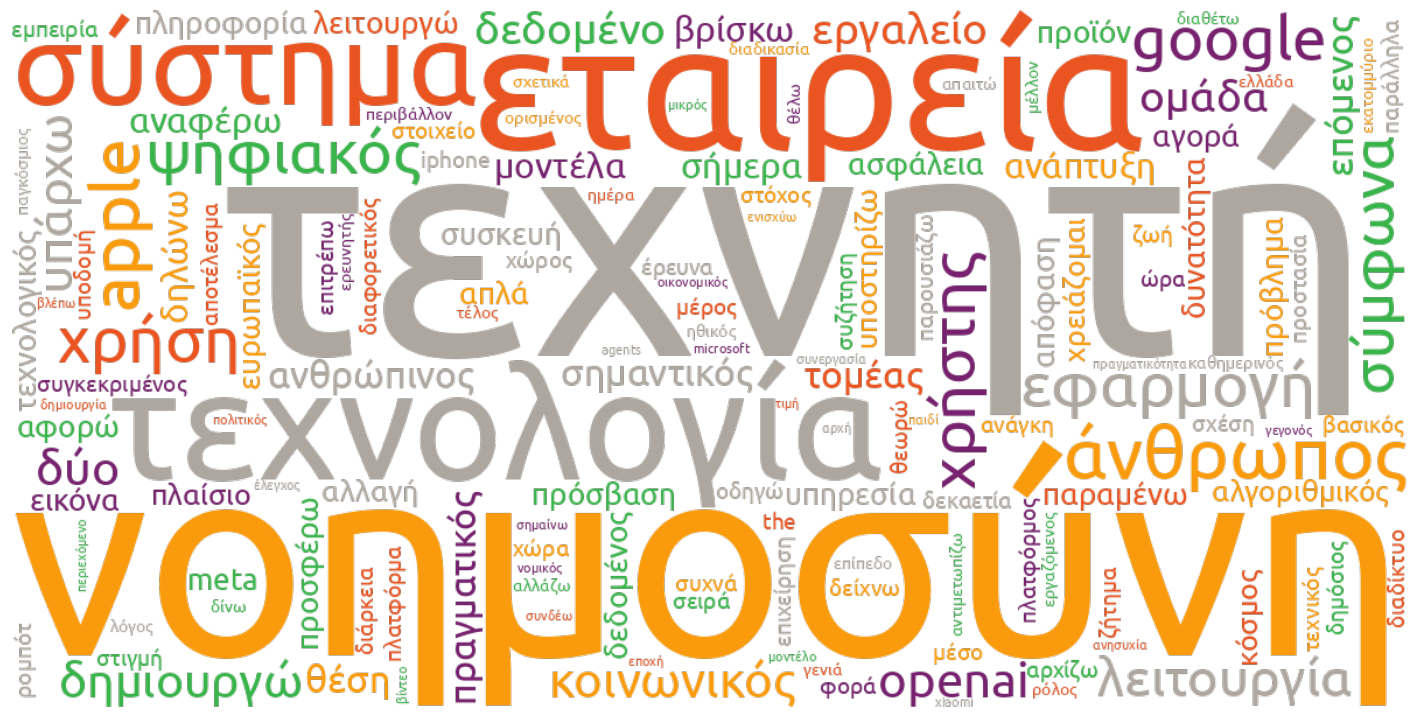

In [ ]:
import random

palette = ["#E95420", "#77216F", "#AEA79F", "#F99B0C", "#38B44A"]

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(palette)

wc = WordCloud(
    width=1200, height=600,
    mode='RGBA', background_color=None,   # διάφανο φόντο
    font_path=ubuntu_font,
    color_func=color_func,
    max_words=150
).generate_from_frequencies(freq)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# αποθήκευση με πραγματική διαφάνεια
wc.to_file("wordcloud.png")

In [ ]:
top_n = 30
top_df = pd.DataFrame(freq.most_common(top_n), columns=['λέξη', 'συχνότητα'])
top_df.index = top_df.index + 1   # η αρίθμηση να ξεκινά από το 1
top_df

,λέξη,συχνότητα
1,τεχνητή,4038
2,νοημοσύνη,3824
3,εταιρεία,2466
4,τεχνολογία,1893
5,σύστημα,1788
6,άνθρωπος,1715
7,apple,1550
8,χρήση,1323
9,εφαρμογή,1266
10,χρήστης,1264


In [ ]:
text = texnologia_mme['text_lemmatized'].apply(' '.join)
mask = text.str.contains(r'τεχνητ(?:ός|ή|ό|ής|ά)\s+νοημοσύνη', regex=True, na=False)
print(f"{mask.sum()} από {len(texnologia_mme)} άρθρα ({mask.mean():.1%})")

358 από 819 άρθρα (43.7%)


In [ ]:
occurrences = text.str.count(r'τεχνητ(?:ός|ή|ό|ής|ά)\s+νοημοσύνη').sum()
print("Συνολικές εμφανίσεις:", occurrences)

Συνολικές εμφανίσεις: 3702


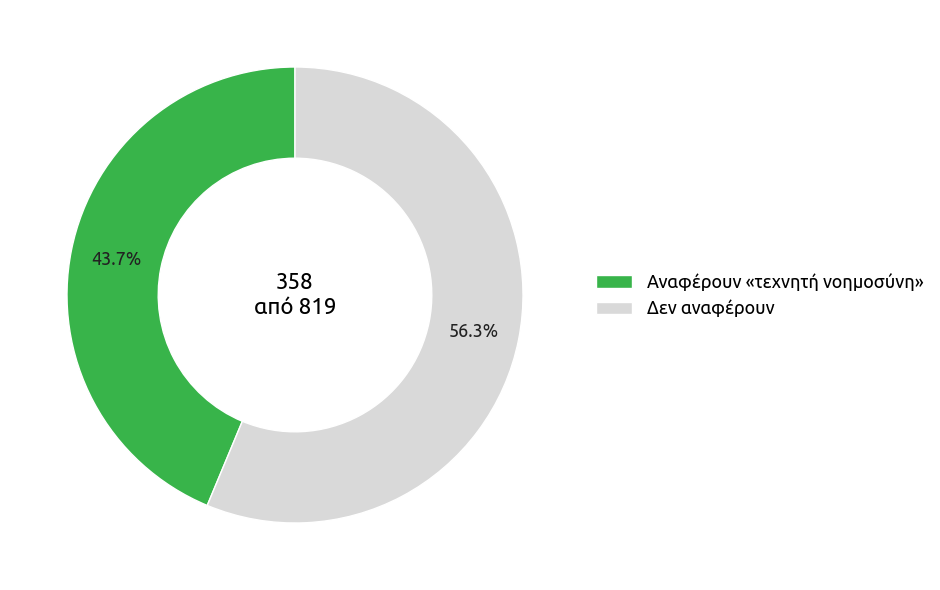

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_manager.fontManager.addfont(ubuntu_font)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=ubuntu_font).get_name()

n_with = mask.sum()
n_without = len(mask) - n_with

fig, ax = plt.subplots(figsize=(9, 6))
wedges, _, autotexts = ax.pie(
    [n_with, n_without],
    colors=['#38B44A', '#D9D9D9'],          # πράσινο / ανοιχτό γκρι
    autopct='%1.1f%%', startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# τα ποσοστά μέσα στο donut
for t in autotexts:
    t.set_fontsize(13)
    t.set_color('#222222')

# ο αριθμός στο κέντρο
ax.text(0, 0, f"{n_with}\nαπό {len(mask)}", ha='center', va='center', fontsize=16)

# οι ετικέτες δίπλα στο γράφημα, όχι πάνω του
ax.legend(
    wedges, ['Αναφέρουν «τεχνητή νοημοσύνη»', 'Δεν αναφέρουν'],
    loc='center left', bbox_to_anchor=(1, 0.5),
    frameon=False, fontsize=13
)

plt.tight_layout()
plt.show()

In [ ]:
src_frames = {"CNN.gr": cnn_df, "To Vima": tovima_df, "Newsit": newsit_df,
              "DNews": dnews_df, "Newsbomb": newsbomb_df}

lookup = (pd.concat([d[['full_text']].assign(source=name) for name, d in src_frames.items()])
          .drop_duplicates('full_text')
          .set_index('full_text')['source'])

texnologia_mme['source'] = texnologia_mme['full_text'].map(lookup)
print(texnologia_mme['source'].isna().sum(), "άρθρα χωρίς μέσο")   # πρέπει 0
print(texnologia_mme['source'].value_counts())

0 άρθρα χωρίς μέσο
source
Newsbomb    399
CNN.gr      214
DNews       149
To Vima      40
Newsit       18
Name: count, dtype: int64


In [ ]:
print(texnologia_mme.columns.tolist())

['source', 'site', 'url', 'title', 'date', 'author', 'full_text', 'datetime']


In [ ]:
!pip install -q spacy wordcloud nltk pandas matplotlib
!python -m spacy download el_core_news_sm

import os, re, unicodedata, urllib.request
import pandas as pd
import spacy, nltk
import matplotlib.pyplot as plt
from matplotlib import font_manager
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

GITHUB_USER, GITHUB_REPO, GITHUB_BRANCH = "annatsamoyra-prog", "data-story-", "main"
def raw_url(f): return f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{f}"

cnn_df      = pd.read_csv(raw_url("cnn_gr_tech_2026.csv"), encoding="utf-8-sig")
tovima_df   = pd.read_csv(raw_url("tovima_texnologia_2026_clean.csv"), encoding="utf-8-sig")
newsit_df   = pd.read_csv(raw_url("newsit_gr_texnologia_2026.csv"), encoding="utf-8-sig")
dnews_df    = pd.read_csv(raw_url("dnews_texnologia_2026.csv"), encoding="utf-8-sig")
newsbomb_df = pd.read_csv(raw_url("newsbomb_technologia_2026.csv"), encoding="utf-8-sig")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 63.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
PROJECT = "/content/drive/MyDrive/data_story"
os.makedirs(PROJECT, exist_ok=True)
MASTER_PATH = f"{PROJECT}/master.pkl"

dfs = {"CNN.gr": cnn_df, "To Vima": tovima_df, "Newsit": newsit_df,
       "DNews": dnews_df, "Newsbomb": newsbomb_df}

master = (pd.concat([d.assign(outlet=name) for name, d in dfs.items()], ignore_index=True)
            .dropna(subset=['title', 'full_text'])
            .drop_duplicates(subset=['full_text'])
            .reset_index(drop=True))
master['doc_id'] = range(len(master))

nlp = spacy.load("el_core_news_sm", disable=["parser", "ner"])

url_re, mention_re, space_re = re.compile(r'https?://\S+|www\.\S+'), re.compile(r'@\w+'), re.compile(r'\s+')
def mild_text_clean(t):
    t = mention_re.sub(" ", url_re.sub(" ", str(t)))
    return space_re.sub(" ", t).strip()

def lemmatize_with_pos(series, batch_size=50):
    lemmas, poses = [], []
    for doc in nlp.pipe(series.astype(str), batch_size=batch_size):
        l, p = [], []
        for t in doc:
            if t.is_alpha and t.lemma_.strip():
                for w in t.lemma_.lower().split():
                    l.append(w); p.append(t.pos_)
        lemmas.append(l); poses.append(p)
    return lemmas, poses

master['text_lemmas'],  master['text_pos']  = lemmatize_with_pos(master['full_text'].apply(mild_text_clean))
master['title_lemmas'], master['title_pos'] = lemmatize_with_pos(master['title'].apply(mild_text_clean))

master.to_pickle(MASTER_PATH)
print("Αποθηκεύτηκε:", master.shape)

Αποθηκεύτηκε: (819, 19)


(819, 23) 358 άρθρα με τεχνητή νοημοσύνη
          with_ai  total        pct
outlet                             
Newsbomb      137    398  34.422111
DNews          64    149  42.953020
Newsit          9     18  50.000000
CNN.gr        120    214  56.074766
To Vima        28     40  70.000000


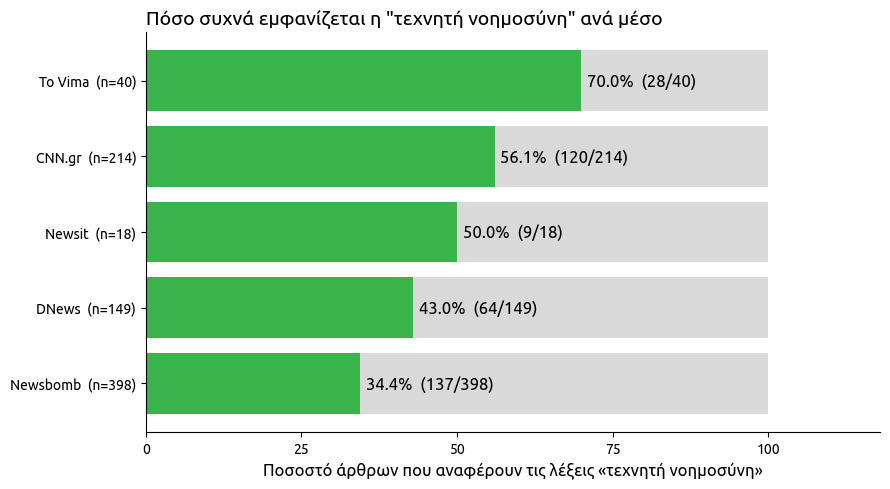

In [ ]:
import os, unicodedata, urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager
from nltk.corpus import stopwords

# ---- Features ----
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

CUSTOM_STOPS = {"ο", "σε", "μπορώ", "γίνομαι", "κάνω", "αποτελώ", "χρησιμοποιώ",
                "νέος", "μεγάλος", "πολύς", "χρόνος", "τρόπος", "εργασία",
                "λέω", "έχω", "είμαι", "θα", "να", "και", "υπάρχω", "δημιουργώ", "σύμφωνα"}
FIX = {"τεχνητός": "τεχνητή", "τεχνητής": "τεχνητή", "τεχνητό": "τεχνητή", "τεχνητά": "τεχνητή"}
stop_norm = {strip_accents(w.lower()) for w in set(stopwords.words('greek')) | CUSTOM_STOPS}

def build_features(master, keep_pos=None):
    d = master.copy()
    def clean(lemmas, poses):
        out = []
        for w, p in zip(lemmas, poses):
            w = FIX.get(w, w)
            if len(w) > 2 and strip_accents(w) not in stop_norm and (keep_pos is None or p in keep_pos):
                out.append(w)
        return out
    d['text_lemmatized_nostopwrds']  = [clean(l, p) for l, p in zip(d['text_lemmas'],  d['text_pos'])]
    d['title_lemmatized_nostopwrds'] = [clean(l, p) for l, p in zip(d['title_lemmas'], d['title_pos'])]
    d['titleandtext'] = (d['title_lemmatized_nostopwrds'] + d['text_lemmatized_nostopwrds']).apply(' '.join)
    pat = r'τεχνητ(?:ός|ή|ό|ής|ά)\s+νοημοσύνη'
    d['has_ai'] = d['text_lemmas'].apply(' '.join).str.contains(pat, regex=True)
    return d

df = build_features(master)
print(df.shape, df['has_ai'].sum(), "άρθρα με τεχνητή νοημοσύνη")

# ---- Στατιστικά ανά μέσο ----
stats = df.groupby('outlet')['has_ai'].agg(with_ai='sum', total='count')
stats['pct'] = stats['with_ai'] / stats['total'] * 100
stats = stats.sort_values('pct')
print(stats)

# ---- Γραμματοσειρά Ubuntu ----
ubuntu_font = "Ubuntu-Regular.ttf"
if not os.path.exists(ubuntu_font):
    urllib.request.urlretrieve(
        "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", ubuntu_font)
font_manager.fontManager.addfont(ubuntu_font)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=ubuntu_font).get_name()

# ---- Γράφημα ----
labels = [f"{s}  (n={int(t)})" for s, t in zip(stats.index, stats['total'])]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, 100, color='#D9D9D9')                    # γκρι = 100% των άρθρων
bars = ax.barh(labels, stats['pct'], color='#38B44A')    # πράσινο = αναφέρουν
ax.bar_label(bars,
             labels=[f"{p:.1f}%  ({int(w)}/{int(t)})"
                     for p, w, t in zip(stats['pct'], stats['with_ai'], stats['total'])],
             padding=4, fontsize=12)
ax.set_xlim(0, 118)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('Ποσοστό άρθρων που αναφέρουν τις λέξεις «τεχνητή νοημοσύνη»', fontsize=12)
ax.set_title('Πόσο συχνά εμφανίζεται η "τεχνητή νοημοσύνη" ανά μέσο', fontsize=14, loc='left')
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig("ai_per_outlet.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
import re

# λέξεις-κλειδιά (ολόκληρες λέξεις, όχι κομμάτι άλλης λέξης)
kw_pattern = re.compile(r'\b(?:ai|openai|anthropic|llms|chatgpt|claude|gemini|deepseek|bot|generative?)\b', re.IGNORECASE)

# ψάχνουμε σε τίτλο + κείμενο
raw = df['title'].astype(str) + ' ' + df['full_text'].astype(str)
df['has_kw'] = raw.str.contains(kw_pattern)

# μόνο τα άρθρα ΧΩΡΙΣ «τεχνητή νοημοσύνη»
no_phrase = df[~df['has_ai']]
n_no = len(no_phrase)
n_kw = no_phrase['has_kw'].sum()

print(f"Άρθρα χωρίς «τεχνητή νοημοσύνη»: {n_no} ({n_no/len(df):.1%} του συνόλου)")
print(f"Από αυτά, με ai/openai/anthropic/LLM: {n_kw} ({n_kw/n_no:.1%})")
print(f"Άρθρα χωρίς κανένα από τα δύο: {n_no - n_kw} ({(n_no - n_kw)/len(df):.1%} του συνόλου)")

# ποια λέξη πιάνεται πόσο συχνά (στα άρθρα χωρίς τη φράση)
found = (no_phrase.loc[no_phrase['has_kw'], 'title'].astype(str) + ' ' +
         no_phrase.loc[no_phrase['has_kw'], 'full_text'].astype(str))
counts = found.str.findall(kw_pattern).explode().str.lower().value_counts()
print(counts)

# ανά μέσο
by_outlet = (no_phrase.groupby('outlet')['has_kw']
             .agg(with_kw='sum', total='count'))
by_outlet['pct'] = by_outlet['with_kw'] / by_outlet['total'] * 100
print(by_outlet.sort_values('pct', ascending=False))

Άρθρα χωρίς «τεχνητή νοημοσύνη»: 461 (56.3% του συνόλου)
Από αυτά, με ai/openai/anthropic/LLM: 53 (11.5%)
Άρθρα χωρίς κανένα από τα δύο: 408 (49.8% του συνόλου)
ai         100
gemini      32
openai      25
chatgpt     12
bot          3
claude       2
llms         2
Name: count, dtype: int64
          with_kw  total        pct
outlet                             
DNews          22     85  25.882353
To Vima         2     12  16.666667
Newsit          1      9  11.111111
CNN.gr         10     94  10.638298
Newsbomb       18    261   6.896552


cat       phrase  kw_only  none  σύνολο
outlet                                 
Σύνολο       358       53   408     819
Newsbomb     137       18   243     398
Newsit         9        1     8      18
DNews         64       22    63     149
CNN.gr       120       10    84     214
To Vima       28        2    10      40


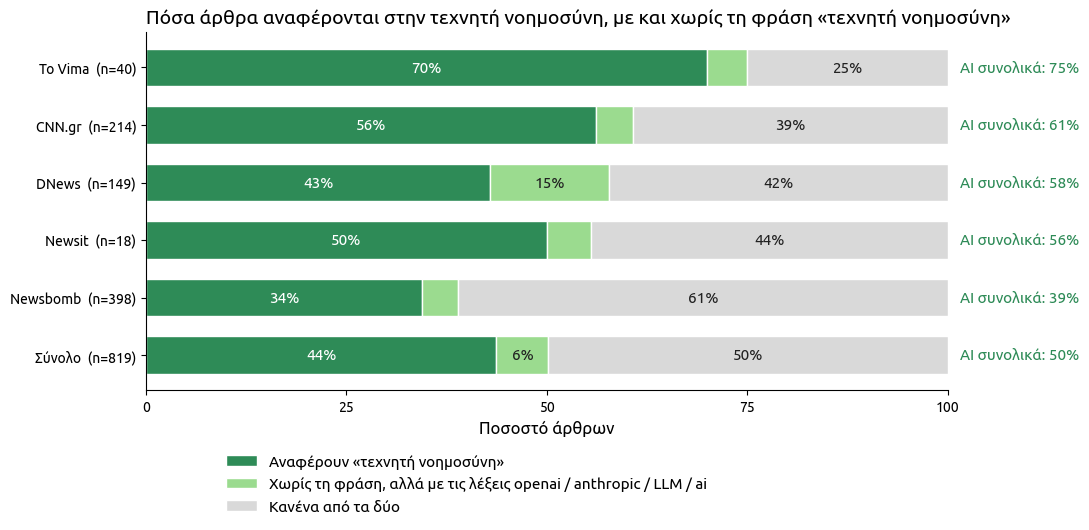

In [ ]:
import re, os, urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- has_kw (αν δεν υπάρχει ήδη) ----
if 'has_kw' not in df.columns:
    kw_pattern = re.compile(r'\b(?:ai|openai|anthropic|llms?)\b', re.IGNORECASE)
    raw = df['title'].astype(str) + ' ' + df['full_text'].astype(str)
    df['has_kw'] = raw.str.contains(kw_pattern)

# ---- κατηγορία ανά άρθρο ----
def category(r):
    if r['has_ai']:
        return 'phrase'
    return 'kw_only' if r['has_kw'] else 'none'

df['cat'] = df.apply(category, axis=1)

order = ['phrase', 'kw_only', 'none']
names = {'phrase':  'Αναφέρουν «τεχνητή νοημοσύνη»',
         'kw_only': 'Χωρίς τη φράση, αλλά με τις λέξεις openai / anthropic / LLM / ai',
         'none':    'Κανένα από τα δύο'}
colors = {'phrase': '#2E8B57', 'kw_only': '#9BDB8F', 'none': '#D9D9D9'}

# ---- πίνακας ανά μέσο + Σύνολο ----
counts = pd.crosstab(df['outlet'], df['cat']).reindex(columns=order, fill_value=0)
counts.loc['Σύνολο'] = counts.sum()
pct = counts.div(counts.sum(axis=1), axis=0) * 100
pct['ai_any'] = pct['phrase'] + pct['kw_only']

# το Σύνολο τελευταίο, τα υπόλοιπα ταξινομημένα κατά συνολική ΑΙ
body = pct.drop('Σύνολο').sort_values('ai_any')
pct = pd.concat([pct.loc[['Σύνολο']], body])      # η πρώτη γραμμή σχεδιάζεται κάτω
counts = counts.loc[pct.index]
print(counts.assign(σύνολο=counts.sum(axis=1)))

# ---- γραμματοσειρά Ubuntu ----
ubuntu_font = "Ubuntu-Regular.ttf"
if not os.path.exists(ubuntu_font):
    urllib.request.urlretrieve(
        "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", ubuntu_font)
font_manager.fontManager.addfont(ubuntu_font)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=ubuntu_font).get_name()

# ---- γράφημα ----
labels = [f"{o}  (n={int(counts.loc[o].sum())})" for o in pct.index]

fig, ax = plt.subplots(figsize=(11, 5.5))
left = pd.Series(0.0, index=pct.index)
for c in order:
    bars = ax.barh(labels, pct[c], left=left.values, color=colors[c],
                   label=names[c], edgecolor='white', height=0.65)
    # ποσοστό μέσα στο τμήμα, μόνο αν χωράει
    ax.bar_label(bars,
                 labels=[f"{v:.0f}%" if v >= 6 else "" for v in pct[c]],
                 label_type='center', fontsize=11,
                 color='white' if c == 'phrase' else '#222222')
    left += pct[c]

# συνολική ΑΙ στο τέλος κάθε ράβδου
for i, o in enumerate(pct.index):
    ax.text(101.5, i, f"ΑΙ συνολικά: {pct.loc[o, 'ai_any']:.0f}%",
            va='center', fontsize=11, fontweight='bold', color='#2E8B57')

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('Ποσοστό άρθρων', fontsize=12)
ax.set_title('Πόσα άρθρα αναφέρονται στην τεχνητή νοημοσύνη, με και χωρίς τη φράση «τεχνητή νοημοσύνη»',
             fontsize=14, loc='left')
ax.legend(loc='upper center', bbox_to_anchor=(0.4, -0.14), ncol=1, frameon=False, fontsize=11)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig("ai_phrase_vs_keywords.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

[(('τεχνητή', 'νοημοσύνη'), 1930), (('redmi', 'note'), 189), (('κοινωνικής', 'δικτύωσης'), 142), (('πρώτη', 'φορά'), 106), (('στις', 'ηπα'), 87), (('διευθύνων', 'σύμβουλος'), 78), (('social', 'media'), 76), (('huawei', 'watch'), 73), (('θέσεις', 'εργασίας'), 70), (('μεταξύ', 'άλλων'), 67), (('ai', 'agents'), 66), (('πραγματικό', 'χρόνο'), 65), (('μέσα', 'κοινωνικής'), 64), (('τελευταία', 'χρόνια'), 63), (('κινητής', 'τηλεφωνίας'), 62)]


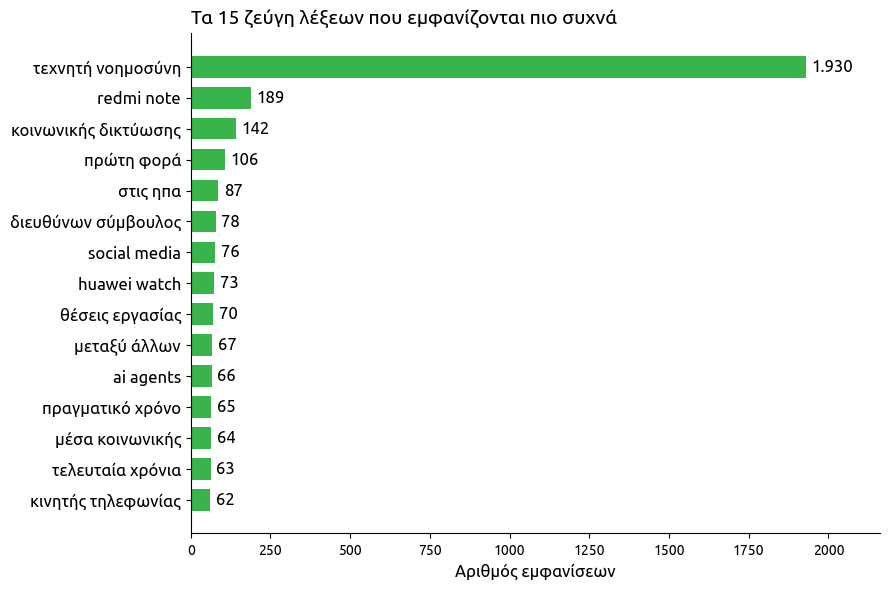

In [ ]:
import re, os, urllib.request
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- stopwords ----
CUSTOM_STOPS |= {"ένας","μία", "στους","ένα","cnn", "pro", "μία","έχει","ήδη""όσον","αφορά","πιο", "μου", "όπως","σας", "μέχρι", "όσα", "όχι", "μόνο", "πλέον"}
stop_norm = {strip_accents(w.lower()) for w in set(stopwords.words('greek')) | CUSTOM_STOPS}

# ενοποίηση των πτώσεων της βασικής φράσης (χωρίς lemmatization)
FIX_RAW = {"τεχνητός": "τεχνητή", "τεχνητής": "τεχνητή", "τεχνητό": "τεχνητή",
           "τεχνητά": "τεχνητή", "τεχνητές": "τεχνητή", "τεχνητών": "τεχνητή",
           "νοημοσύνης": "νοημοσύνη"}

# ---- γραμματοσειρά Ubuntu ----
ubuntu_font = "Ubuntu-Regular.ttf"
if not os.path.exists(ubuntu_font):
    urllib.request.urlretrieve(
        "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", ubuntu_font)
font_manager.fontManager.addfont(ubuntu_font)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=ubuntu_font).get_name()

# ---- tokenization χωρίς lemmatization ----
url_re = re.compile(r'https?://\S+|www\.\S+')
split_re = re.compile(r'[.!?;:…\n]+|[«»"()\[\]]')             # τα ζεύγη δεν περνούν από τη μία πρόταση στην άλλη
word_re = re.compile(r'[a-z\u0370-\u03ff\u1f00-\u1fff]+')    # ελληνικά και λατινικά, χωρίς αριθμούς

def ok(w):
    return (len(w) > 2 or w == 'ai') and strip_accents(w) not in stop_norm

def raw_bigrams(text):
    out = []
    for sent in split_re.split(url_re.sub(' ', str(text)).lower()):
        toks = [FIX_RAW.get(w, w) for w in word_re.findall(sent)]
        out += [(a, b) for a, b in zip(toks, toks[1:]) if ok(a) and ok(b) and a != b]
    return out

bg_counter = Counter()
for title, text in zip(df['title'], df['full_text']):
    bg_counter.update(raw_bigrams(title))      # τίτλος και κείμενο χωριστά
    bg_counter.update(raw_bigrams(text))

top = bg_counter.most_common(15)
print(top)

labels = [f"{a} {b}" for (a, b), _ in top][::-1]
counts = [c for _, c in top][::-1]

# ---- γράφημα ----
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, counts, color='#38B44A', height=0.7)
ax.bar_label(bars, labels=[f"{c:,}".replace(",", ".") for c in counts], padding=4, fontsize=12)
ax.set_xlim(0, max(counts) * 1.12)
ax.set_xlabel('Αριθμός εμφανίσεων', fontsize=12)
ax.set_title('Τα 15 ζεύγη λέξεων που εμφανίζονται πιο συχνά', fontsize=14, loc='left')
ax.tick_params(axis='y', labelsize=12)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig("top15_bigrams_raw.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

outlet
Newsbomb    398
CNN.gr      214
DNews       149
To Vima      40
Newsit       18
Name: count, dtype: int64


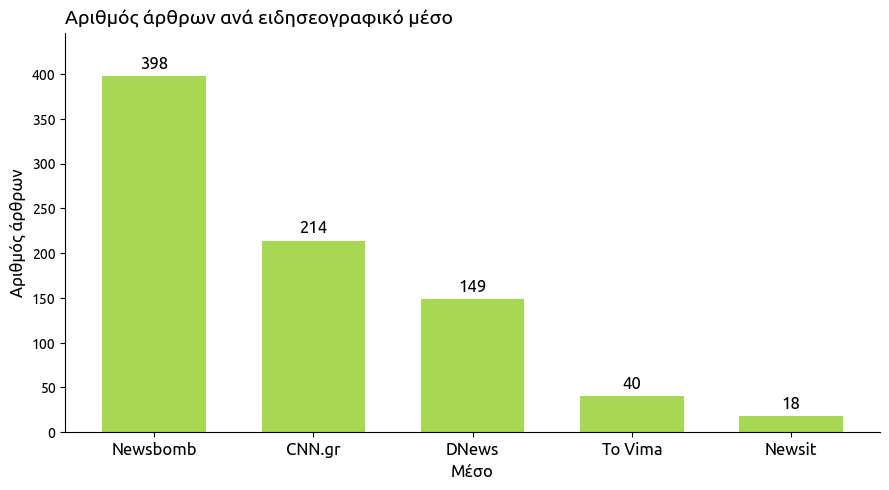

In [ ]:
import os, urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- γραμματοσειρά Ubuntu ----
ubuntu_font = "Ubuntu-Regular.ttf"
if not os.path.exists(ubuntu_font):
    urllib.request.urlretrieve(
        "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", ubuntu_font)
font_manager.fontManager.addfont(ubuntu_font)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=ubuntu_font).get_name()

# ---- πόσα άρθρα ανά μέσο ----
counts = df['outlet'].value_counts()
print(counts)

# ---- γράφημα ----
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values, color='#A6D854', width=0.65)   # λαχανί
ax.bar_label(bars, padding=3, fontsize=12)

ax.set_title('Αριθμός άρθρων ανά ειδησεογραφικό μέσο', fontsize=14, loc='left')
ax.set_xlabel('Μέσο', fontsize=12)
ax.set_ylabel('Αριθμός άρθρων', fontsize=12)
ax.set_ylim(0, counts.max() * 1.12)
ax.tick_params(axis='x', labelsize=12, rotation=0)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig("articles_per_outlet.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
df['num_words'] = df['text_lemmatized_nostopwrds'].apply(len)
df['num_words'].describe()
df.groupby('outlet')['num_words'].describe()

,count,mean,std,min,25%,50%,75%,max
outlet,,,,,,,,
CNN.gr,214.0,334.154206,239.171083,30.0,199.25,293.0,401.00,1931.0
DNews,149.0,341.355705,198.293431,38.0,201.00,315.0,432.00,1121.0
Newsbomb,398.0,288.155779,234.276067,3.0,158.25,256.5,374.75,3262.0
Newsit,18.0,291.777778,181.674096,26.0,156.50,295.5,428.75,666.0
To Vima,40.0,7035.875000,6942.384683,78.0,3464.25,4793.0,7956.75,38383.0


<Axes: title={'center': 'Διάμεσο μήκος άρθρων ανά μέσο'}, xlabel='Μέσο', ylabel='Αριθμός λέξεων'>

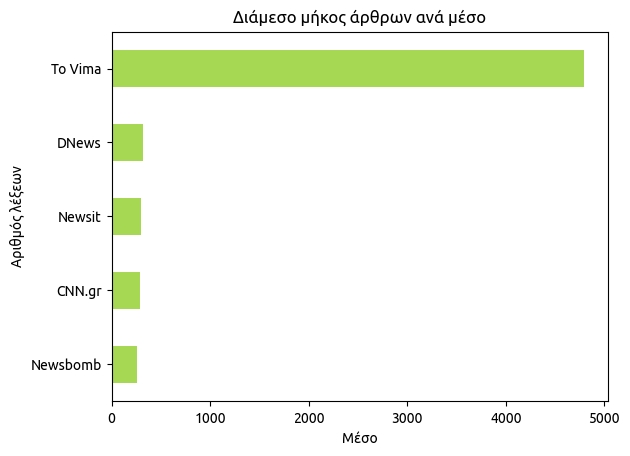

In [ ]:
df.groupby('outlet')['num_words'].median().sort_values().plot(
    kind='barh',
    color='#A6D854',
    title='Διάμεσο μήκος άρθρων ανά μέσο',
    xlabel='Μέσο',
    ylabel='Αριθμός λέξεων'
)

In [ ]:
import re

def dup_ratio(text):
    # σπάμε σε προτάσεις και μετράμε ποσοστό επαναλαμβανόμενων
    parts = [p.strip() for p in re.split(r'(?<=[.!?;·»])\s+', str(text)) if len(p.strip()) > 30]
    return 1 - len(set(parts)) / len(parts) if parts else 0

df['dup_ratio'] = df['full_text'].apply(dup_ratio)
print(df.groupby('outlet')['dup_ratio'].describe().round(2))

          count  mean   std  min  25%  50%  75%   max
outlet                                               
CNN.gr    214.0   0.0  0.00  0.0  0.0  0.0  0.0  0.04
DNews     149.0   0.0  0.01  0.0  0.0  0.0  0.0  0.06
Newsbomb  398.0   0.0  0.01  0.0  0.0  0.0  0.0  0.17
Newsit     18.0   0.0  0.00  0.0  0.0  0.0  0.0  0.00
To Vima    40.0   0.0  0.00  0.0  0.0  0.0  0.0  0.00


In [ ]:
import re

def dedupe_text(text):
    parts = re.split(r'(?<=[.!?;·»])\s+', str(text))
    seen, out = set(), []
    for p in parts:
        key = p.strip()
        if key and key not in seen:
            seen.add(key)
            out.append(key)
    return ' '.join(out)

mask_tv = master['outlet'] == 'To Vima'

# 1. καθάρισμα κειμένου μόνο στο To Vima
master.loc[mask_tv, 'full_text'] = master.loc[mask_tv, 'full_text'].apply(dedupe_text)

# 2. ξανά lemmatization μόνο σε αυτά τα 40 άρθρα
tv_lem, tv_pos = lemmatize_with_pos(master.loc[mask_tv, 'full_text'].apply(mild_text_clean))
master.loc[mask_tv, 'text_lemmas'] = pd.Series(tv_lem, index=master.index[mask_tv])
master.loc[mask_tv, 'text_pos']    = pd.Series(tv_pos, index=master.index[mask_tv])

# 3. αποθήκευση και νέα features
master.to_pickle(MASTER_PATH)
df = build_features(master)

# 4. έλεγχος
df['num_words'] = df['full_text'].str.split().str.len()
print(df.groupby('outlet')['num_words'].describe().round(0))
print(df.groupby('outlet')['has_ai'].mean().round(3) * 100)

          count    mean    std    min     25%     50%     75%     max
outlet                                                               
CNN.gr    214.0   582.0  420.0   60.0   350.0   504.0   708.0  3431.0
DNews     149.0   585.0  338.0   63.0   352.0   539.0   721.0  1945.0
Newsbomb  398.0   499.0  428.0    7.0   284.0   442.0   640.0  6325.0
Newsit     18.0   509.0  310.0   44.0   287.0   506.0   784.0  1150.0
To Vima    40.0  1583.0  795.0  129.0  1072.0  1525.0  2020.0  4014.0
outlet
CNN.gr      56.1
DNews       43.0
Newsbomb    34.4
Newsit      50.0
To Vima     70.0
Name: has_ai, dtype: float64


In [ ]:
import re

def dedupe_text(text):
    parts = re.split(r'(?<=[.!?;·»])\s+', str(text))
    seen, out = set(), []
    for p in parts:
        key = p.strip()
        if key and key not in seen:
            seen.add(key)
            out.append(key)
    return ' '.join(out)

mask_tv = master['outlet'] == 'To Vima'

# 1. καθάρισμα κειμένου μόνο στο To Vima
master.loc[mask_tv, 'full_text'] = master.loc[mask_tv, 'full_text'].apply(dedupe_text)

# 2. ξανά lemmatization μόνο σε αυτά τα 40 άρθρα
tv_lem, tv_pos = lemmatize_with_pos(master.loc[mask_tv, 'full_text'].apply(mild_text_clean))
master.loc[mask_tv, 'text_lemmas'] = pd.Series(tv_lem, index=master.index[mask_tv])
master.loc[mask_tv, 'text_pos']    = pd.Series(tv_pos, index=master.index[mask_tv])

# 3. αποθήκευση και νέα features
master.to_pickle(MASTER_PATH)
df = build_features(master)

# 4. έλεγχος
df['num_words'] = df['full_text'].str.split().str.len()
print(df.groupby('outlet')['num_words'].describe().round(0))
print(df.groupby('outlet')['has_ai'].mean().round(3) * 100)

          count    mean    std    min     25%     50%     75%     max
outlet                                                               
CNN.gr    214.0   582.0  420.0   60.0   350.0   504.0   708.0  3431.0
DNews     149.0   585.0  338.0   63.0   352.0   539.0   721.0  1945.0
Newsbomb  398.0   499.0  428.0    7.0   284.0   442.0   640.0  6325.0
Newsit     18.0   509.0  310.0   44.0   287.0   506.0   784.0  1150.0
To Vima    40.0  1583.0  795.0  129.0  1072.0  1525.0  2020.0  4014.0
outlet
CNN.gr      56.1
DNews       43.0
Newsbomb    34.4
Newsit      50.0
To Vima     70.0
Name: has_ai, dtype: float64


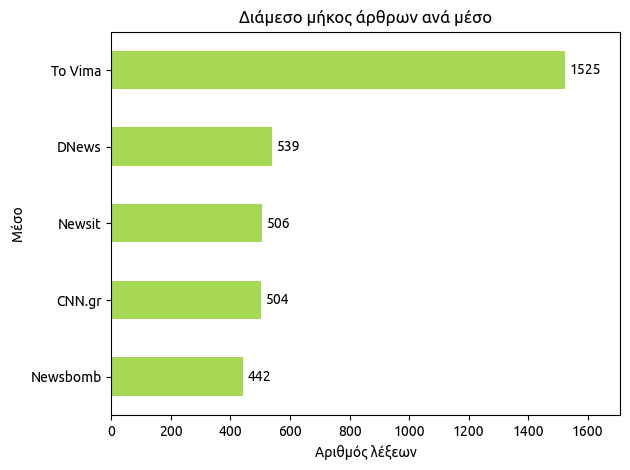

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_manager.fontManager.addfont("Ubuntu-Regular.ttf")
plt.rcParams['font.family'] = font_manager.FontProperties(fname="Ubuntu-Regular.ttf").get_name()

df['num_words'] = df['full_text'].astype(str).str.split().str.len()

med = df.groupby('outlet')['num_words'].median().sort_values()

ax = med.plot(kind='barh', color='#A6D854', title='Διάμεσο μήκος άρθρων ανά μέσο')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
ax.set_xlim(0, med.max() * 1.12)
plt.xlabel('Αριθμός λέξεων')
plt.ylabel('Μέσο')
plt.tight_layout()
plt.show()

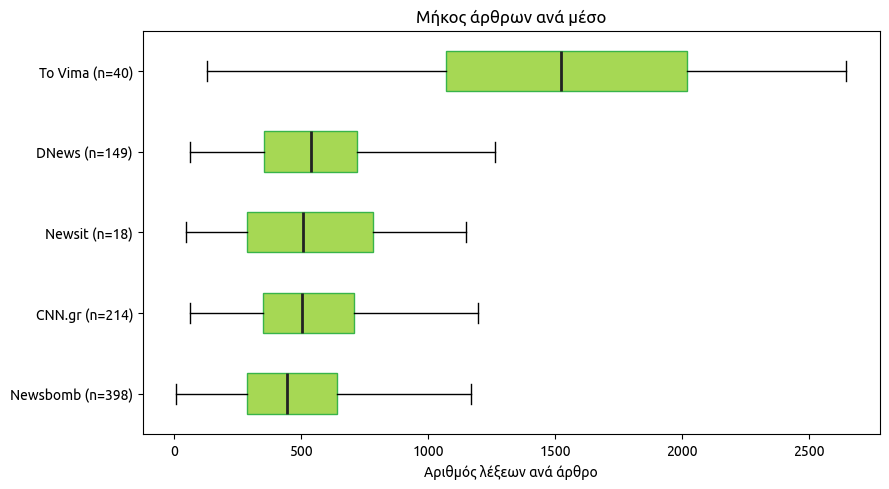

In [ ]:
rder = df.groupby('outlet')['num_words'].median().sort_values().index
data = [df.loc[df['outlet'] == o, 'num_words'] for o in order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, vert=False, patch_artist=True, showfliers=False,
                medianprops=dict(color='#222222', linewidth=2))
for box in bp['boxes']:
    box.set(facecolor='#A6D854', edgecolor='#38B44A')
ax.set_yticklabels([f"{o} (n={len(d)})" for o, d in zip(order, data)])
ax.set_xlabel('Αριθμός λέξεων ανά άρθρο')
ax.set_title('Μήκος άρθρων ανά μέσο')
plt.tight_layout()
plt.show()

# **Topic Modelling**

Topic models είναι μια οικογένεια μεθόδων που μας βοηθούν να εντοπίσουμε επαναλαμβανόμενα θεματικά μοτίβα μέσα σε ένα μεγάλο σύνολο κειμένων. Η βασική ιδέα είναι ότι λέξεις που εμφανίζονται συχνά μαζί πιθανόν να σχετίζονται με το ίδιο θέμα. Έτσι, ένα «θέμα» δεν είναι μια έτοιμη κατηγορία που δίνουμε εμείς στον υπολογιστή, αλλά ένα σύνολο λέξεων που τείνουν να συνυπάρχουν σε πολλά κείμενα. Ένα από τα πιο γνωστά μοντέλα θεμάτων είναι το Latent Dirichlet Allocation (LDA). Το LDA είναι ένα πιθανοκρατικό μοντέλο που υποθέτει ότι κάθε κείμενο αποτελείται από ένα μείγμα διαφορετικών θεμάτων, ενώ κάθε θέμα αντιστοιχεί σε μια κατανομή λέξεων. Για παράδειγμα, ένα θέμα σχετικό με το ποδόσφαιρο μπορεί να δίνει υψηλή πιθανότητα σε λέξεις όπως «προπονητής», «γκολ» ή «πέναλτι», ενώ ένα πολιτικό θέμα μπορεί να περιλαμβάνει συχνότερα λέξεις όπως «εκλογές», «βουλή» ή «κυβέρνηση». Σημείωση: topic models δεν «καταλαβαίνουν» πραγματικά το νόημα όπως ένας άνθρωπος· αντίθετα, εντοπίζουν στατιστικά μοτίβα συνύπαρξης λέξεων. Η ερμηνεία των θεμάτων παραμένει πάντα ένα ερευνητικό βήμα που απαιτεί κριτική σκέψη και γνώση του περιεχομένου των κειμένων

In [ ]:
import shutil, os

if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
    shutil.rmtree("/content/drive")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q spacy
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 27.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
   import os, urllib.request
   if not os.path.exists("Ubuntu-Regular.ttf"):
       urllib.request.urlretrieve(
           "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", "Ubuntu-Regular.ttf")

In [ ]:
for name in ['master', 'build_features', 'stop_norm', 'FIX']:
    print(name, name in globals())

master True
build_features False
stop_norm False
FIX False


In [ ]:
import glob
print(glob.glob("/content/**/*.pkl", recursive=True))

[]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Phrases, LdaModel, CoherenceModel
from gensim.corpora import Dictionary

# --- Start of added code to ensure master DataFrame is available ---
import os, re, unicodedata, urllib.request
import spacy
import nltk
from nltk.corpus import stopwords
import numpy as np # Often a dependency for pandas or matplotlib

# Define PROJECT and MASTER_PATH
PROJECT = "/content/drive/MyDrive/data_story"
os.makedirs(PROJECT, exist_ok=True)
MASTER_PATH = f"{PROJECT}/master.pkl"

# Check if master.pkl exists, if not, create it
if not os.path.exists(MASTER_PATH):
    print("master.pkl not found. Recreating master DataFrame...")
    # Ensure spacy model and nltk stopwords are available for recreation process
    # This addresses OSError [E050] and ensures stopwords are loaded.
    !python -m spacy download el_core_news_sm -q
    nltk.download('stopwords', quiet=True)

    # Re-define GITHUB constants and raw_url function (from earlier cells)
    GITHUB_USER = "annatsamoyra-prog"
    GITHUB_REPO = "data-story-"
    GITHUB_BRANCH = "main"
    def raw_url(filename: str) -> str:
        return f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{filename}"

    # Load individual dataframes (from cell Uk7CW3dwtJzg)
    cnn_df = pd.read_csv(raw_url("cnn_gr_tech_2026.csv"), encoding="utf-8-sig")
    tovima_df = pd.read_csv(raw_url("tovima_texnologia_2026_clean.csv"), encoding="utf-8-sig")
    newsit_df = pd.read_csv(raw_url("newsit_gr_texnologia_2026.csv"), encoding="utf-8-sig")
    dnews_df = pd.read_csv(raw_url('dnews_texnologia_2026.csv'), encoding="utf-8-sig")
    newsbomb_df = pd.read_csv(raw_url('newsbomb_technologia_2026.csv'), encoding="utf-8-sig")

    # Drop columns from tovima_df (from cell _bHZLX6LB9BC)
    tovima_df = tovima_df.drop(columns=['full_text_clean', 'tokenized', 'no_stop', 'num_wds', 'uniq_wds', 'Text_id'], errors='ignore')

    # Concatenate dataframes to create master (from cell tK-YqtRLAGYX)
    dfs = {"CNN.gr": cnn_df, "To Vima": tovima_df, "Newsit": newsit_df, "DNews": dnews_df, "Newsbomb": newsbomb_df}
    master = (pd.concat([d.assign(outlet=name) for name, d in dfs.items()], ignore_index=True)
                .dropna(subset=['title', 'full_text'])
                .drop_duplicates(subset=['full_text'])
                .reset_index(drop=True))
    master['doc_id'] = range(len(master))

    # Initialize spacy nlp model (from cell tK-YqtRLAGYX)
    nlp = spacy.load("el_core_news_sm", disable=["parser", "ner"])

    # Define mild_text_clean and lemmatize_with_pos (from cell tK-YqtRLAGYX)
    url_re, mention_re, space_re = re.compile(r'https?://\S+|www\.\S+'), re.compile(r'@\w+'), re.compile(r'\s+')
    def mild_text_clean(t):
        t = mention_re.sub(" ", url_re.sub(" ", str(t)))
        return space_re.sub(" ", t).strip()

    def lemmatize_with_pos(series, batch_size=50):
        lemmas, poses = [], []
        for doc in nlp.pipe(series.astype(str), batch_size=batch_size):
            l, p = [], []
            for t in doc:
                if t.is_alpha and t.lemma_.strip():
                    for w in t.lemma_.lower().split():
                        l.append(w); p.append(t.pos_)
            lemmas.append(l); poses.append(p)
        return lemmas, poses

    master['text_lemmas'],  master['text_pos']  = lemmatize_with_pos(master['full_text'].apply(mild_text_clean))
    master['title_lemmas'], master['title_pos'] = lemmatize_with_pos(master['title'].apply(mild_text_clean))

    # Save master dataframe
    master.to_pickle(MASTER_PATH)
    print("master DataFrame recreated and saved.")
else:
    print("master.pkl found. Loading master DataFrame...")
# Load master dataframe (whether newly created or existing)
master = pd.read_pickle(MASTER_PATH)
print("master DataFrame loaded.")

# Ensure spacy model and nltk stopwords are available even if master.pkl was found
!python -m spacy download el_core_news_sm -q
nltk.download('stopwords', quiet=True)

# Re-load spacy nlp model (even if master was loaded, nlp needs to be initialized in this session)
nlp = spacy.load("el_core_news_sm", disable=["parser", "ner"])

# Re-define helper functions and constants for build_features (from cell BWRSWvN9BLN3)
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

CUSTOM_STOPS = {"ο", "σε", "μπορώ", "γίνομαι", "κάνω", "αποτελώ", "χρησιμοποιώ",
                "νέος", "μεγάλος", "πολύς", "χρόνος", "τρόπος", "εργασία",
                "λέω", "έχω", "είμαι", "θα", "να", "και", "υπάρχω", "δημιουργώ", "σύμφωνα"}
FIX = {"τεχνητός": "τεχνητή", "τεχνητής": "τεχνητή", "τεχνητό": "τεχνητή", "τεχνητά": "τεχνητή"}
stop_norm = {strip_accents(w.lower()) for w in set(stopwords.words('greek')) | CUSTOM_STOPS}

def build_features(master, keep_pos=None):
    d = master.copy()
    def clean(lemmas, poses):
        out = []
        for w, p in zip(lemmas, poses):
            w = FIX.get(w, w)
            if len(w) > 2 and strip_accents(w) not in stop_norm and (keep_pos is None or p in keep_pos):
                out.append(w)
        return out
    d['text_lemmatized_nostopwrds']  = [clean(l, p) for l, p in zip(d['text_lemmas'],  d['text_pos'])]
    d['title_lemmatized_nostopwrds'] = [clean(l, p) for l, p in zip(d['title_lemmas'], d['title_pos'])]
    d['titleandtext'] = (d['title_lemmatized_nostopwrds'] + d['text_lemmatized_nostopwrds']).apply(' '.join)
    pat = r'τεχνητ(?:ός|ή|ό|ής|ά)\s+νοημοσύνη'
    d['has_ai'] = d['text_lemmas'].apply(' '.join).str.contains(pat, regex=True)
    return d
# --- End of added code ---

dft = build_features(master, keep_pos={'NOUN', 'PROPN'})

docs = [list(t) + list(x) for t, x in zip(dft['title_lemmatized_nostopwrds'],
                                          dft['text_lemmatized_nostopwrds'])]
print(len(docs), docs[2][:25])

master.pkl not found. Recreating master DataFrame...
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
master DataFrame recreated and saved.
master DataFrame loaded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 34.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
819 ['κείμενο', 'δευτέρα', 'ιανουάριος', 'εργαλείο', 'νοημοσύνη', 'κείμενο', 'ιδρύμα', 'επιχείρηση', 'καταναλωτής', 'άνθρωπο', 'μ

In [ ]:
# bigrams (π.χ. "υπουργείο_ψηφιακής")
bigram = Phrases(docs, min_count=5, threshold=10)
for d in docs:
    d.extend([tok for tok in bigram[d] if '_' in tok])

dictionary = Dictionary(docs)
print("Μοναδικές λέξεις πριν:", len(dictionary))

# ποιες πολύ συχνές λέξεις θα φύγουν (εμφανίζονται σε >25% των άρθρων)
too_common = [w for w, n in dictionary.dfs.items() if n / len(docs) > 0.25]
print("Θα αφαιρεθούν:", [dictionary[i] for i in too_common])

dictionary.filter_extremes(no_below=5, no_above=0.25)
print("Μοναδικές λέξεις μετά:", len(dictionary))

corpus = [dictionary.doc2bow(d) for d in docs]

Μοναδικές λέξεις πριν: 15603
Θα αφαιρεθούν: ['χρήστης', 'επιμέλεια', 'νοημοσύνη', 'εταιρεία', 'υπηρεσία', 'εργαλείο', 'χρήση', 'εφαρμογή', 'άνθρωπος', 'σύστημα', 'πληροφορία', 'δεδομένο', 'λειτουργία', 'στιγμή', 'τεχνολογία', 'ασφάλεια', 'στόχος', 'δυνατότητα', 'φορά', 'ανάπτυξη']
Μοναδικές λέξεις μετά: 2741


K= 4  coherence=0.546 ± 0.028
K= 6  coherence=0.555 ± 0.003
K= 8  coherence=0.532 ± 0.005
K=10  coherence=0.565 ± 0.003
K=12  coherence=0.565 ± 0.002
K=14  coherence=0.573 ± 0.028
K=16  coherence=0.602 ± 0.029


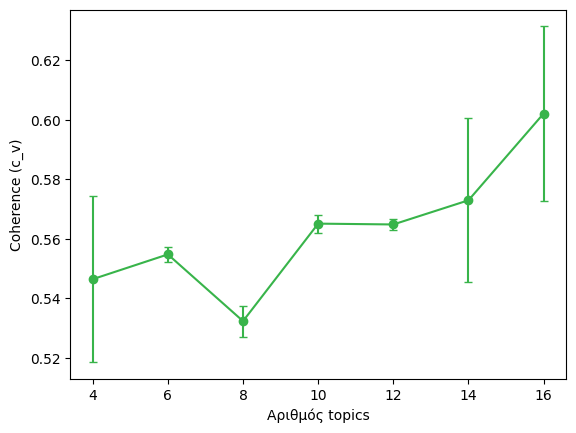

In [ ]:
import logging, numpy as np
import matplotlib.pyplot as plt
from gensim.models import LdaModel, CoherenceModel

logging.getLogger("gensim").setLevel(logging.ERROR)   # κρύβει τα warnings

ks_try = [4, 6, 8, 10, 12, 14, 16]
seeds = [1, 2]            # 2 τρεξίματα ανά K για πιο σταθερό αποτέλεσμα
results = {}

for k in ks_try:
    sc = []
    for s in seeds:
        m = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                     passes=15, iterations=200, chunksize=len(corpus),
                     alpha='auto', eta='auto', random_state=s)
        c = CoherenceModel(model=m, texts=docs, dictionary=dictionary,
                           coherence='c_v', processes=1).get_coherence()
        sc.append(c)
    results[k] = (np.mean(sc), np.std(sc))
    print(f"K={k:2d}  coherence={results[k][0]:.3f} ± {results[k][1]:.3f}")

ks = list(results)
mean = [results[k][0] for k in ks]
std = [results[k][1] for k in ks]

plt.errorbar(ks, mean, yerr=std, marker='o', capsize=3, color='#38B44A')
plt.xlabel('Αριθμός topics')
plt.ylabel('Coherence (c_v)')
plt.xticks(ks)
plt.show()

In [ ]:
for K in [6, 10]:
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K,
                   passes=20, iterations=400, chunksize=len(corpus),
                   alpha='auto', eta='auto', random_state=42)
    print(f"\n===== K = {K} =====")
    for t in range(K):
        print(f"Topic {t}:", ", ".join(w for w, _ in lda.show_topic(t, 10)))

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().re


===== K = 6 =====
Topic 0: σειρά, εμπειρία, συσκευή, ώρα, χώρος, πλατφόρμα, συνεργασία, διοργάνωση, ημέρα, προϊόν
Topic 1: αποστολή, ερευνητής, ομάδα, κίνηση, περιοχή, μελέτη, διάστημα, πρόγραμμα, πρόβλημα, συσκευή
Topic 2: πρόσβαση, απόφαση, λογαριασμός, στοιχείο, διαδίκτυο, μήνας, μοντέλα, διαδικασία, περίπτωση, αναζήτηση
Topic 3: εικόνα, επιτροπή, αγώνας, παιδί, περιεχόμενο, γνώση, σου, σχεδιασμός, μπάλα, ακρίβεια
Topic 4: τεχνητή, αγορά, θέση, τομέας, iphone, σχέση, μοντέλα, προϊόν, υποδομή, ανάγκη
Topic 5: ομάδα, πλατφόρμος, τομέας, δεκαετία, μέσο, πλαίσιο, ζήτημα, παιδί, πλατφόρμα, αντίσταση


Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().re


===== K = 10 =====
Topic 0: σειρά, εμπειρία, συσκευή, ώρα, φωτογραφία, κάμερα, μπαταρία, μέρα, agents, πλατφόρμα
Topic 1: αποστολή, αγώνας, εικόνα, ακρίβεια, ταχύτητα, γεγονός, διάστημα, πρόγραμμα, δευτερόλεπτο, επιστήμονας
Topic 2: απόφαση, πρόσβαση, λογαριασμός, ελλάδα, μήνας, αναζήτηση, διαδικασία, έλεγχος, αποτέλεσμα, περίπτωση
Topic 3: επιτροπή, εικόνα, γνώση, περιεχόμενο, σου, σχεδιασμός, ευθύνη, θέση, περιορισμός, όριο
Topic 4: iphone, αγορά, θέση, μοντέλα, τομέας, υποδομή, τεχνητή, προϊόν, συσκευή, πρόσβαση
Topic 5: ομάδα, πλατφόρμος, τομέας, πλαίσιο, αλγόριθμο, αντίσταση, πλατφόρμα, προβολή, οργάνωση, εργαζόμενος
Topic 6: παιδί, δεκαετία, πρόβλημα, ζωή, υγεία, διαδίκτυο, ομάδα, έρευνα, ηλικία, δικτύωση
Topic 7: διοργάνωση, μηνύματα, συνεργασία, πρόσβαση, απόφαση, συνάντηση, αθήνα, αγωγή, προϊόν, άκρο
Topic 8: τεχνητή, μέλλον, τομέας, ποσοστό, ανησυχία, δουλειά, θέση, δημιουργία, πολίτης, γυναίκα
Topic 9: δοκιμή, υπολογιστής, κώδικας, τζομπς, μοντέλα, συσκευή, κίνηση, διαδίκτυ

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore")

for t in range(lda.num_topics):
    words = ", ".join(w for w, _ in lda.show_topic(t, 12))
    print(f"Topic {t}: {words}")

Topic 0: σειρά, εμπειρία, συσκευή, ώρα, φωτογραφία, κάμερα, μπαταρία, μέρα, agents, πλατφόρμα, τιμή, απόδοση
Topic 1: αποστολή, αγώνας, εικόνα, ακρίβεια, ταχύτητα, γεγονός, διάστημα, πρόγραμμα, δευτερόλεπτο, επιστήμονας, δορυφόρος, μπάλα
Topic 2: απόφαση, πρόσβαση, λογαριασμός, ελλάδα, μήνας, αναζήτηση, διαδικασία, έλεγχος, αποτέλεσμα, περίπτωση, αριθμός, εργαζόμενος
Topic 3: επιτροπή, εικόνα, γνώση, περιεχόμενο, σου, σχεδιασμός, ευθύνη, θέση, περιορισμός, όριο, έλεγχος, κινδύνους
Topic 4: iphone, αγορά, θέση, μοντέλα, τομέας, υποδομή, τεχνητή, προϊόν, συσκευή, πρόσβαση, σχέση, ανάγκη
Topic 5: ομάδα, πλατφόρμος, τομέας, πλαίσιο, αλγόριθμο, αντίσταση, πλατφόρμα, προβολή, οργάνωση, εργαζόμενος, οικονομία, ζήτημα
Topic 6: παιδί, δεκαετία, πρόβλημα, ζωή, υγεία, διαδίκτυο, ομάδα, έρευνα, ηλικία, δικτύωση, ερευνητής, μέσο
Topic 7: διοργάνωση, μηνύματα, συνεργασία, πρόσβαση, απόφαση, συνάντηση, αθήνα, αγωγή, προϊόν, άκρο, εκπαίδευση, μηνυμάτων
Topic 8: τεχνητή, μέλλον, τομέας, ποσοστό, ανησυχ

In [ ]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("gensim").setLevel(logging.ERROR)

from gensim.models import Phrases, LdaModel
from gensim.corpora import Dictionary

CUSTOM_STOPS |= {"τεχνητή", "τεχνητός", "νοημοσύνη", "μήνας", "ώρα", "μέρα", "θέση",
                 "αριθμός", "περίπτωση", "πρόσβαση", "τομέας", "σου", "άκρο", "τζομπς",
                 "μοντέλα", "σειρά", "μέσο", "ζήτημα", "σχέση", "ανάγκη"}
FIX.update({"πλατφόρμος": "πλατφόρμα", "αλγόριθμο": "αλγόριθμος",
            "κινδύνους": "κίνδυνος", "μηνυμάτων": "μήνυμα", "μηνύματα": "μήνυμα"})
stop_norm = {strip_accents(w.lower()) for w in set(stopwords.words('greek')) | CUSTOM_STOPS}
print("Το 'τεχνητή' είναι στα stopwords:", strip_accents("τεχνητή") in stop_norm)

dft = build_features(master, keep_pos={'NOUN', 'PROPN'})
t_col = dft['title_lemmatized_nostopwrds']
x_col = dft['text_lemmatized_nostopwrds']
docs = [list(t) + list(x) for t, x in zip(t_col, x_col)]

bigram = Phrases(docs, min_count=5, threshold=10)
for d in docs:
    d.extend([tok for tok in bigram[d] if '_' in tok])

dictionary = Dictionary(docs)
dictionary.filter_extremes(no_below=5, no_above=0.25)
corpus = [dictionary.doc2bow(d) for d in docs]
print(len(docs), len(dictionary))

Το 'τεχνητή' είναι στα stopwords: True
819 2703


In [ ]:
K = 10
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K,
               passes=20, iterations=400, chunksize=len(corpus),
               alpha='auto', eta='auto', random_state=42)

for t in range(K):
    print(f"Topic {t}:", ", ".join(w for w, _ in lda.show_topic(t, 12)))

Topic 0: πλατφόρμα, ομάδα, αλγόριθμος, αντίσταση, προβολή, εργαζόμενος, οργάνωση, πλαίσιο, ενημέρωση, περιεχόμενο, δράση, οικονομία
Topic 1: επιτροπή, σχεδιασμός, περιεχόμενο, ενέργεια, έλεγχος, απόφαση, κίνδυνος, σήμα, λογαριασμός, εφήβος, πλατφόρμα, ευρώπη
Topic 2: εμπειρία, συσκευή, εικόνα, φωτογραφία, κάμερα, iphone, μπαταρία, κινητό, γυναίκα, ενδιαφέρον, τιμή, διαφορά
Topic 3: αγορά, συσκευή, απόφαση, δίκτυο, εικόνα, υποδομή, ερώτημα, μετάβαση, πεδίο, εποχή, εξάρτηση, όγκος
Topic 4: κώδικας, υπολογιστής, ηπα, δημιουργία, δοκιμή, διαδίκτυο, κυβέρνηση, εβδομάδα, εκατομμύριο, κυβερνοασφάλεια, έτος, συσκευή
Topic 5: προϊόν, iphone, ερευνητής, μέλλον, ομάδα, πρόβλημα, μελέτη, ρόλος, έρευνα, μέρος, εξέλιξη, τιμή
Topic 6: πρόγραμμα, αποστολή, συνεργασία, διοργάνωση, συνάντηση, αθήνα, ελλάδα, ημέρα, ρομπότ, ταχύτητα, διάστημα, δορυφόρος
Topic 7: μήνυμα, απόφαση, επιχείρηση, κυριαρχία, ελλάδα, αγωγή, ρόλος, χώρα, εκπαίδευση, ομάδα, στοιχείο, επίπεδο
Topic 8: αγώνας, πολίτης, ακρίβεια, εικό

Visualize
Ένας καλός τρόπος για να εξετάσουμε τα topics που παρήγαγε το LDA είναι να τα οπτικοποιήσουμε (με pyLDAvis). Η οπτικοποίηση μάς βοηθά να δούμε πόσο συχνό ή «μεγάλο» είναι κάθε topic μέσα στο corpus, πόσο κοντά ή μακριά είναι τα topics μεταξύ τους, ποιες λέξεις είναι πιο χαρακτηριστικές για κάθε topic. Στο γράφημα, κάθε κύκλος αντιστοιχεί σε ένα topic. Μεγαλύτερος κύκλος σημαίνει ότι το topic εμφανίζεται πιο έντονα στο corpus. Όταν δύο κύκλοι είναι κοντά, τα topics έχουν παρόμοιο λεξιλόγιο, όταν είναι μακριά, είναι πιο διακριτά μεταξύ τους.

In [ ]:
#import pyLDAvis
#from pyLDAvis import gensim_models as gensimvis

#pyLDAvis.enable_notebook()
#vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
#pyLDAvis.display(vis)

label
Κυβερνοασφάλεια                                      174
Smartphones και κάμερες                              139
Τεχνολογικά προϊόντα και έρευνα/καινοτομία           135
Διάστημα, ρομποτική και επιστημονικές συνεργασίες    119
Τεχνολογική αγορά και ψηφιακές υποδομές               66
Ρύθμιση και έλεγχος στις ψηφιακές πλατφόρμες          60
Πλατφόρμες, αλγόριθμοι και εργασία                    49
Ψηφιακή πολιτική και επιχειρήσεις                     28
Παιδιά και διαδίκτυο                                  25
Κοινωνικές διαστάσεις της τεχνολογίας                 24
Name: count, dtype: int64


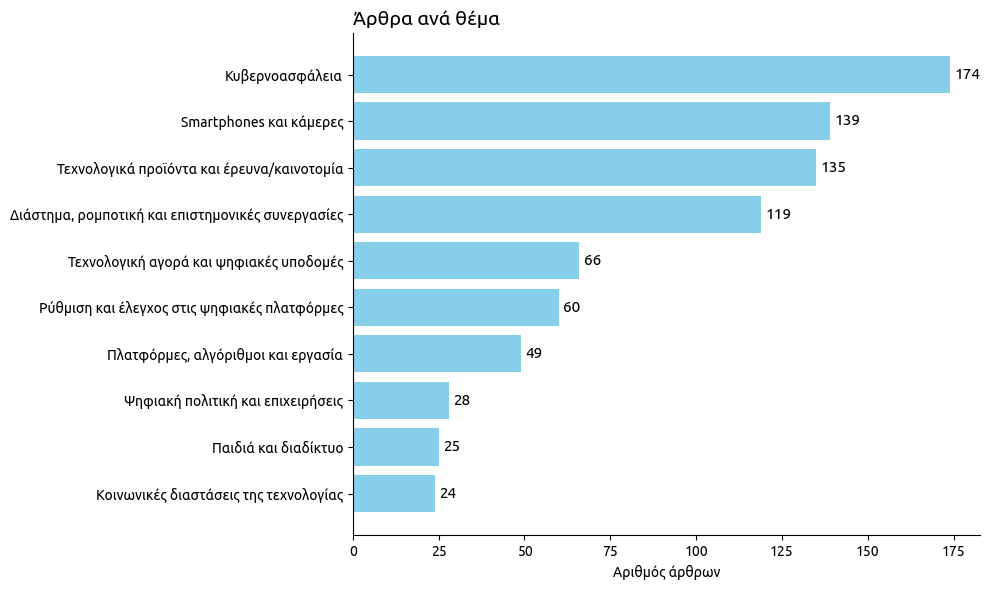

In [ ]:
import pandas as pd, os, urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- ονόματα θεμάτων ----
labels = {
    0: "Πλατφόρμες, αλγόριθμοι και εργασία",
    1: "Ρύθμιση και έλεγχος στις ψηφιακές πλατφόρμες",
    2: "Smartphones και κάμερες",
    3: "Τεχνολογική αγορά και ψηφιακές υποδομές",
    4: "Κυβερνοασφάλεια",
    5: "Τεχνολογικά προϊόντα και έρευνα/καινοτομία",
    6: "Διάστημα, ρομποτική και επιστημονικές συνεργασίες",
    7: "Ψηφιακή πολιτική και επιχειρήσεις",
    8: "Κοινωνικές διαστάσεις της τεχνολογίας",
    9: "Παιδιά και διαδίκτυο",
}

# ---- κυρίαρχο θέμα ανά άρθρο ----
rows = []
for i, bow in enumerate(corpus):
    probs = lda.get_document_topics(bow, minimum_probability=0)
    k, p = max(probs, key=lambda x: x[1])
    rows.append((dft['doc_id'].iloc[i], k, p))

res = pd.DataFrame(rows, columns=['doc_id', 'topic', 'prob'])
res['label'] = res['topic'].map(labels)
res['outlet'] = dft['outlet'].values
res['title'] = dft['title'].values

# ---- αποθήκευση (μοντέλο + αποτελέσματα) ----
res.to_pickle("topics_lda_k10_final.pkl")
lda.save("lda_model_k10_final")
print(res['label'].value_counts())

# ---- γραμματοσειρά ----
try:
    if not os.path.exists("Ubuntu-Regular.ttf"):
        urllib.request.urlretrieve(
            "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", "Ubuntu-Regular.ttf")
    font_manager.fontManager.addfont("Ubuntu-Regular.ttf")
    plt.rcParams['font.family'] = font_manager.FontProperties(fname="Ubuntu-Regular.ttf").get_name()
except Exception as e:
    print("Ubuntu δεν φορτώθηκε:", e)

# ---- γράφημα 1: άρθρα ανά θέμα ----
cnt = res['label'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cnt.index, cnt.values, color='skyblue')
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_xlabel('Αριθμός άρθρων')
ax.set_title('Άρθρα ανά θέμα', loc='left', fontsize=14)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("topics_count.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()


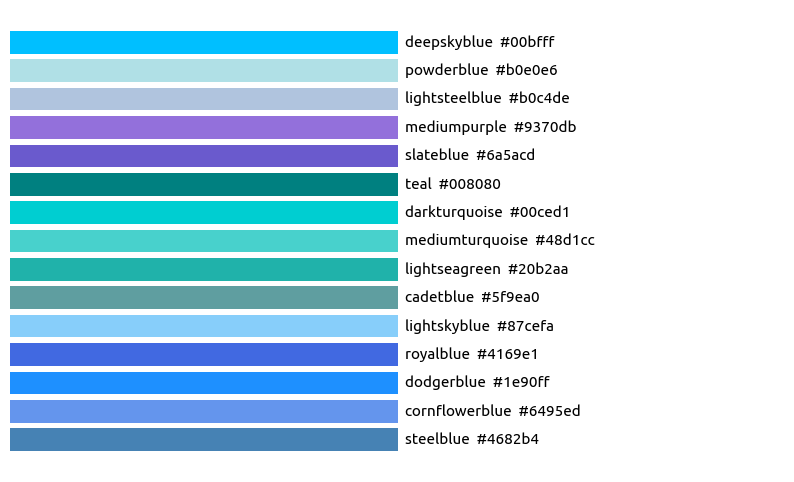

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

names = ['steelblue', 'cornflowerblue', 'dodgerblue', 'royalblue', 'lightskyblue',
         'cadetblue', 'lightseagreen', 'mediumturquoise', 'darkturquoise', 'teal',
         'slateblue', 'mediumpurple', 'lightsteelblue', 'powderblue', 'deepskyblue']

fig, ax = plt.subplots(figsize=(10, 6))
for i, n in enumerate(names):
    ax.barh(i, 1, color=n)
    ax.text(1.02, i, f"{n}  {mcolors.to_hex(n)}", va='center', fontsize=11)
ax.set_xlim(0, 2)
ax.set_yticks([])
ax.axis('off')
plt.show()

outlet                                             CNN.gr  DNews  Newsbomb  \
label                                                                        
Smartphones και κάμερες                               7.9   36.2      15.6   
Διάστημα, ρομποτική και επιστημονικές συνεργασίες    14.0    4.0      20.1   
Κοινωνικές διαστάσεις της τεχνολογίας                 0.5    2.0       3.5   
Κυβερνοασφάλεια                                      36.4   15.4      15.6   
Παιδιά και διαδίκτυο                                  1.9    4.0       2.8   
Πλατφόρμες, αλγόριθμοι και εργασία                    1.9    8.1       7.0   
Ρύθμιση και έλεγχος στις ψηφιακές πλατφόρμες          8.4    8.1       6.8   
Τεχνολογικά προϊόντα και έρευνα/καινοτομία           14.5   12.8      20.1   
Τεχνολογική αγορά και ψηφιακές υποδομές              10.3    7.4       5.8   
Ψηφιακή πολιτική και επιχειρήσεις                     4.2    2.0       2.8   

outlet                                             Newsit  To V

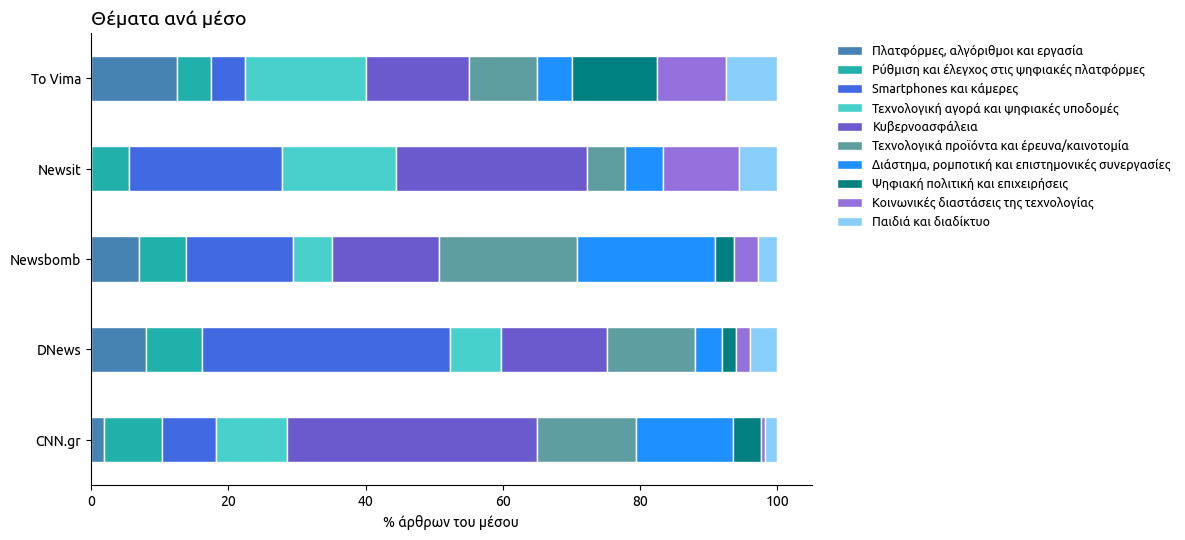

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

palette = ['steelblue', 'lightseagreen', 'royalblue', 'mediumturquoise', 'slateblue',
           'cadetblue', 'dodgerblue', 'teal', 'mediumpurple', 'lightskyblue']

ct = pd.crosstab(res['label'], res['outlet'], normalize='columns') * 100
print(ct.round(1))

# σειρά θεμάτων ίδια με την αρίθμηση 0-9
order = [labels[k] for k in range(10)]
ct = ct.reindex(order)

ax = ct.T.plot(kind='barh', stacked=True, figsize=(12, 5.5),
               color=palette, edgecolor='white')
ax.set_xlabel('% άρθρων του μέσου')
ax.set_ylabel('')
ax.set_title('Θέματα ανά μέσο', loc='left', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("topics_by_outlet.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
import json
import pyLDAvis
from pyLDAvis import gensim_models as gensimvis
from IPython.display import HTML, display

vis = gensimvis.prepare(lda, corpus, dictionary, sort_topics=False)
html = pyLDAvis.prepared_data_to_html(vis)

greek = {
    "Intertopic Distance Map (via multidimensional scaling)": "Χάρτης απόστασης μεταξύ θεμάτων",
    "Marginal topic distribution": "Μέγεθος θέματος στο σύνολο",
    "Top-30 Most Salient Terms": "Οι 30 πιο χαρακτηριστικές λέξεις",
    "Top-30 Most Relevant Terms for Topic": "Οι 30 πιο σχετικές λέξεις για το θέμα",
    "Overall term frequency": "Συνολική συχνότητα λέξης",
    "Estimated term frequency within the selected topic": "Εκτιμώμενη συχνότητα στο επιλεγμένο θέμα",
    "Slide to adjust relevance metric:": "Ρύθμιση σχετικότητας:",
    "Selected Topic:": "Επιλεγμένο θέμα:",
    "Previous Topic": "Προηγούμενο θέμα",
    "Next Topic": "Επόμενο θέμα",
    "Clear Topic": "Καθαρισμός επιλογής",
}

script = """
<script>
(function () {
  const dict = %s;
  const keys = Object.keys(dict).sort((a, b) => b.length - a.length);
  function tr(root) {
    const w = document.createTreeWalker(root, NodeFilter.SHOW_TEXT);
    let n;
    while ((n = w.nextNode())) {
      let t = n.nodeValue, c = t;
      for (const k of keys) { if (c.includes(k)) c = c.split(k).join(dict[k]); }
      if (c !== t) n.nodeValue = c;
    }
  }
  const obs = new MutationObserver(() => tr(document.body));
  obs.observe(document.body, {childList: true, subtree: true, characterData: true});
  setTimeout(() => tr(document.body), 500);
  setTimeout(() => tr(document.body), 2000);
})();
</script>
""" % json.dumps(greek, ensure_ascii=False)
font_css = """
<link href="https://fonts.googleapis.com/css2?family=Ubuntu:wght@400;500;700&display=swap" rel="stylesheet">
<style>
  body, body *, svg text { font-family: 'Ubuntu', sans-serif !important; }
</style>
"""

html_el = font_css + html + script
display(HTML(html_el))

from google.colab import files
files.download("topics_lda_el.html")
# αρχείο για δημοσίευση ή κοινοποίηση
with open("topics_lda_el.html", "w", encoding="utf-8") as f:
    f.write("<meta charset='utf-8'>" + html_el)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Μελλοντικές: 7
month
2026-01     88
2026-02     78
2026-03     97
2026-04     98
2026-05    114
2026-06     91
2026-07     85
2026-08     79
2026-09     82
Freq: M, dtype: int64


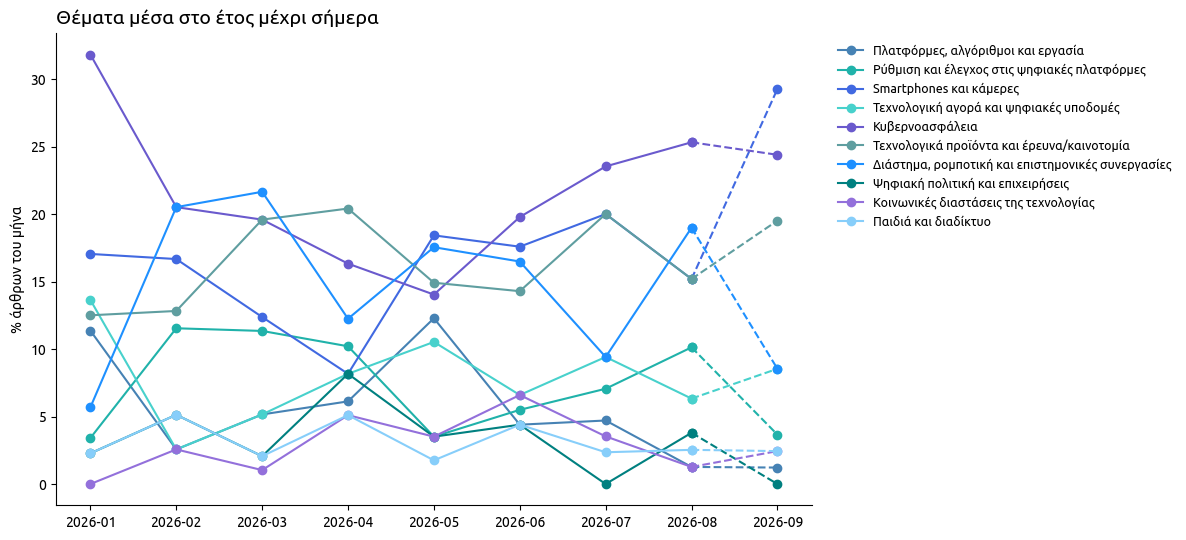

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

palette = ['steelblue', 'lightseagreen', 'royalblue', 'mediumturquoise', 'slateblue',
           'cadetblue', 'dodgerblue', 'teal', 'mediumpurple', 'lightskyblue']

# έλεγχος ότι η διόρθωση εφαρμόστηκε
print("Μελλοντικές:", (res['date'] > pd.Timestamp('2026-09-20')).sum())

# μόνο ημερομηνίες έως 20/9/2026
res_m = res[res['date'] <= pd.Timestamp('2026-09-20 23:59:59')].copy()
res_m['month'] = res_m['date'].dt.to_period('M')

counts = pd.crosstab(res_m['month'], res_m['label'])
counts = counts[[labels[k] for k in range(10) if labels[k] in counts.columns]]
print(counts.sum(axis=1))                      # άρθρα ανά μήνα

share = counts.div(counts.sum(axis=1), axis=0) * 100
x = share.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, col in enumerate(share.columns):
    ax.plot(x[:-1], share[col].iloc[:-1], marker='o', color=palette[i], label=col)
    # Σεπτέμβριος (ημιτελής): διακεκομμένη γραμμή
    ax.plot(x[-2:], share[col].iloc[-2:], marker='o', color=palette[i], linestyle='--')

ax.set_ylabel('% άρθρων του μήνα')
ax.set_title('Θέματα μέσα στο έτος μέχρι σήμερα', loc='left', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("topics_over_time.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

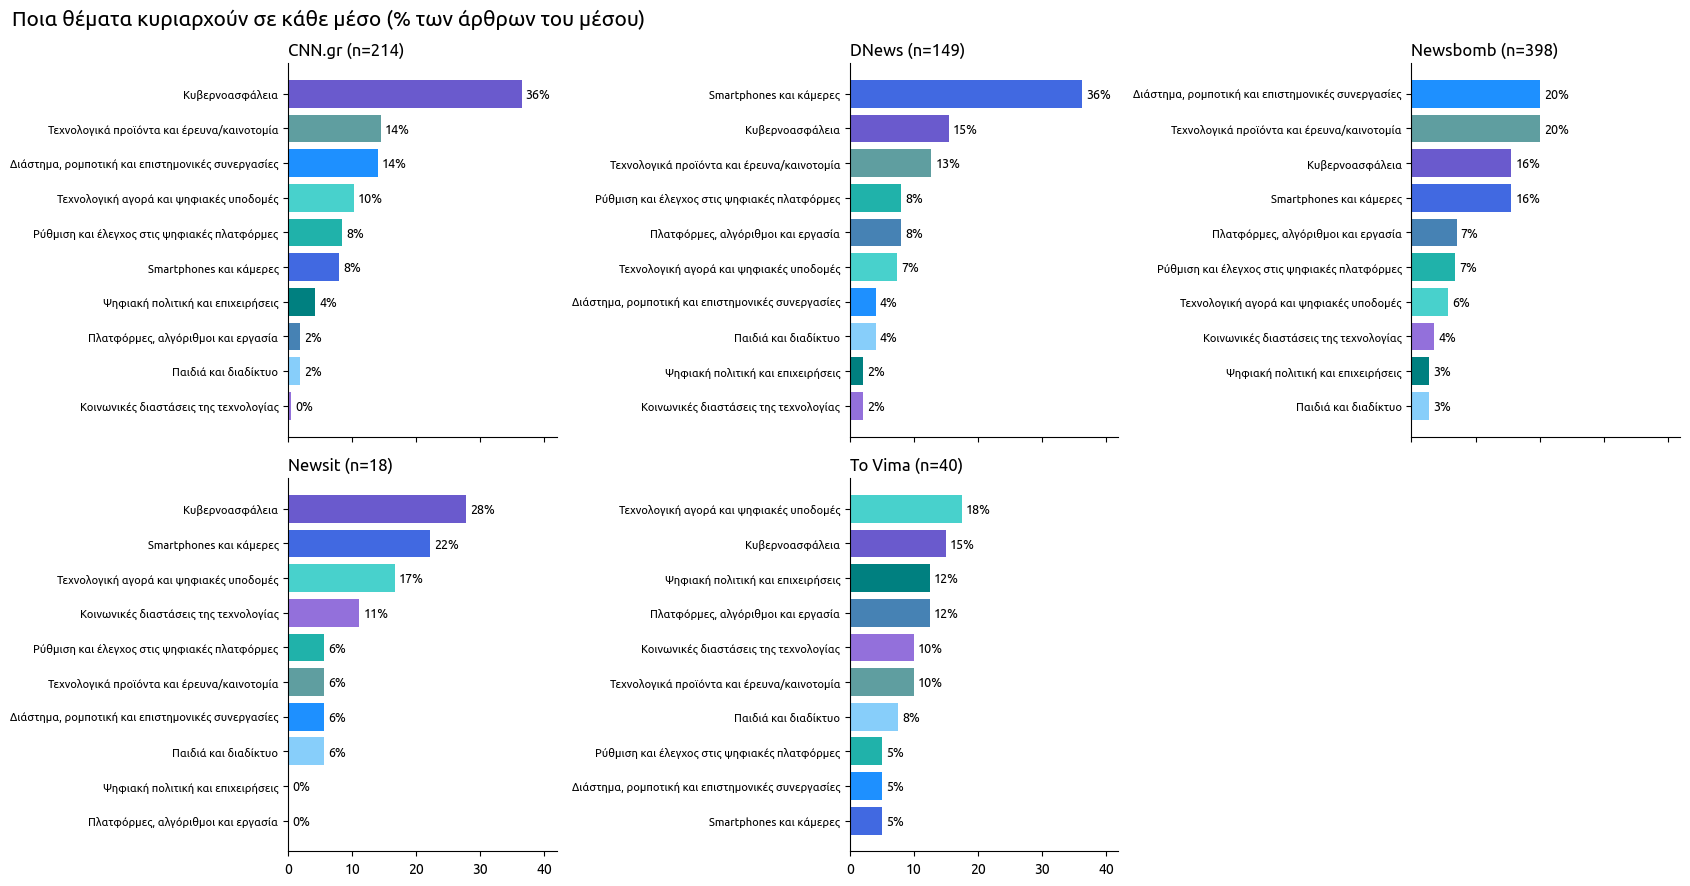

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

palette = ['steelblue', 'lightseagreen', 'royalblue', 'mediumturquoise', 'slateblue',
           'cadetblue', 'dodgerblue', 'teal', 'mediumpurple', 'lightskyblue']
color_of = {labels[k]: palette[k] for k in range(10)}

ct = pd.crosstab(res['label'], res['outlet'], normalize='columns') * 100
n_per = res['outlet'].value_counts()
outlets = ['CNN.gr', 'DNews', 'Newsbomb', 'Newsit', 'To Vima']

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
for ax, o in zip(axes.flat, outlets):
    s = ct[o].sort_values()
    bars = ax.barh(s.index, s.values, color=[color_of[l] for l in s.index])
    ax.bar_label(bars, labels=[f"{v:.0f}%" for v in s.values], padding=3, fontsize=9)
    ax.set_title(f"{o} (n={n_per[o]})", loc='left', fontsize=12)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlim(0, ct.values.max() * 1.15)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

axes.flat[-1].axis('off')

title = "Ποια θέματα κυριαρχούν σε κάθε μέσο"
subtitle = " (% των άρθρων του μέσου)"
fig.suptitle(title + subtitle, x=0.01, ha='left', fontsize=15)

plt.tight_layout()
plt.savefig("topics_per_outlet_panels.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

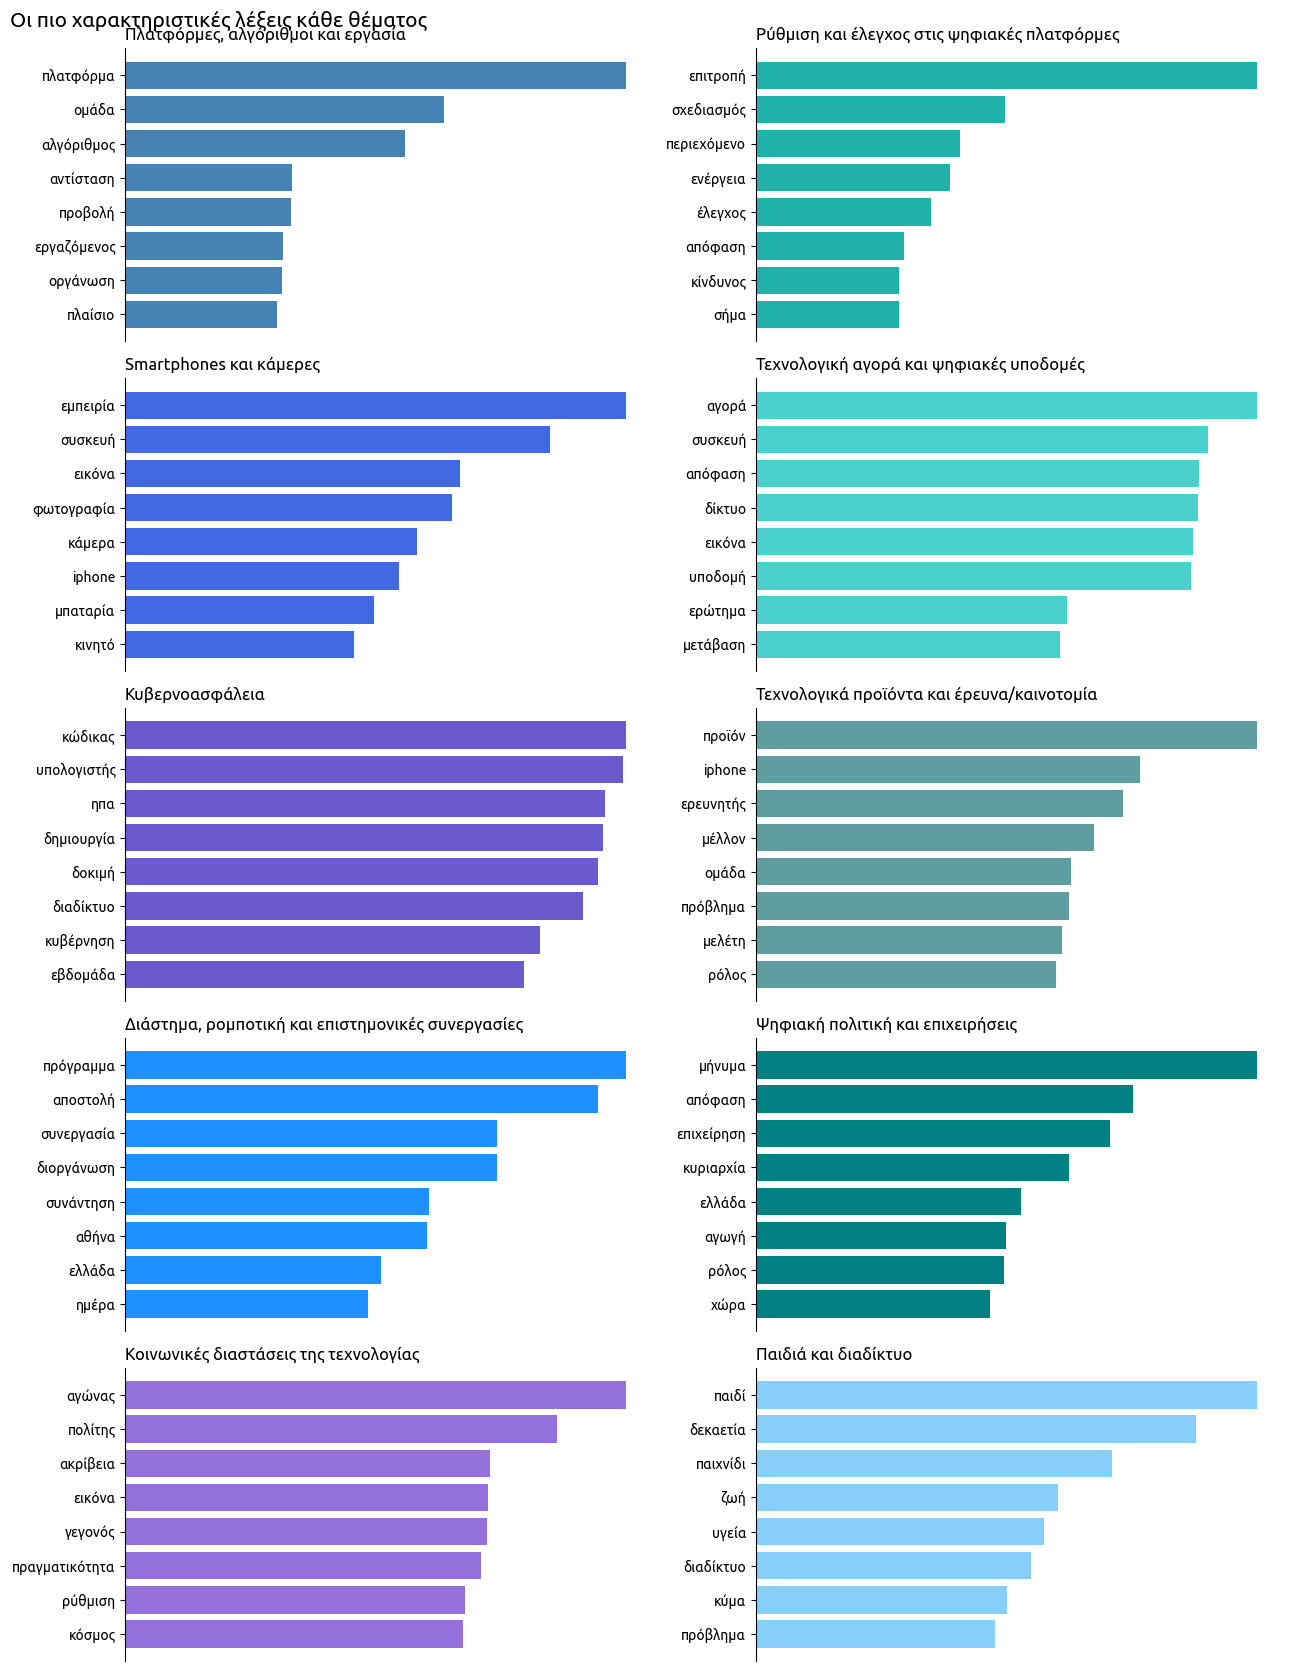

In [ ]:
import math, os, urllib.request
import matplotlib.pyplot as plt
from matplotlib import font_manager

try:
    if not os.path.exists("Ubuntu-Regular.ttf"):
        urllib.request.urlretrieve(
            "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf", "Ubuntu-Regular.ttf")
    font_manager.fontManager.addfont("Ubuntu-Regular.ttf")
    plt.rcParams['font.family'] = font_manager.FontProperties(fname="Ubuntu-Regular.ttf").get_name()
except Exception as e:
    print("Ubuntu δεν φορτώθηκε:", e)

palette = ['steelblue', 'lightseagreen', 'royalblue', 'mediumturquoise', 'slateblue',
           'cadetblue', 'dodgerblue', 'teal', 'mediumpurple', 'lightskyblue']

K = lda.num_topics
cols = 2
n_rows = math.ceil(K / cols)

fig, axes = plt.subplots(n_rows, cols, figsize=(13, 3.4 * n_rows))
for k, ax in enumerate(axes.flat):
    if k < K:
        w, p = zip(*lda.show_topic(k, 8))
        ax.barh(w[::-1], p[::-1], color=palette[k])
        ax.set_title(labels[k], loc='left', fontsize=12)
        ax.set_xticks([])
        for s in ['top', 'right', 'bottom']:
            ax.spines[s].set_visible(False)
    else:
        ax.axis('off')

fig.suptitle('Οι πιο χαρακτηριστικές λέξεις κάθε θέματος', x=0.01, ha='left', fontsize=15)
plt.tight_layout()
plt.savefig("topics_words.png", dpi=200, transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
import os, json, pickle, shutil
from google.colab import drive

if os.path.isdir("/content/drive") and not os.path.ismount("/content/drive"):
    shutil.rmtree("/content/drive")      # τοπικός φάκελος που μπλοκάρει το mount
drive.mount('/content/drive')

P = "/content/drive/MyDrive/data_story"
os.makedirs(P, exist_ok=True)

# δεδομένα και αποτελέσματα
master.to_pickle(f"{P}/master.pkl")
dft.to_pickle(f"{P}/dft_topics.pkl")
res.to_pickle(f"{P}/res_final.pkl")

# μοντέλο, λεξικό, corpus
lda.save(f"{P}/lda_k10_final")
dictionary.save(f"{P}/dictionary.dict")
with open(f"{P}/corpus.pkl", "wb") as f:
    pickle.dump(corpus, f)

# ρυθμίσεις (τα CUSTOM_STOPS και FIX έχουν αλλάξει μέσα στο session)
with open(f"{P}/settings.json", "w", encoding="utf-8") as f:
    json.dump({"custom_stops": sorted(CUSTOM_STOPS), "fix": FIX,
               "labels": {str(k): v for k, v in labels.items()}}, f, ensure_ascii=False, indent=1)

# τα γραφήματα και το διαδραστικό
for name in os.listdir("."):
    if name.endswith((".png", ".html")):
        shutil.copy(name, P)

print(sorted(os.listdir(P)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['corpus.pkl', 'dft_topics.pkl', 'dictionary.dict', 'lda_k10_final', 'lda_k10_final.expElogbeta.npy', 'lda_k10_final.id2word', 'lda_k10_final.state', 'master.pkl', 'res_final.pkl', 'settings.json', 'topics_by_outlet.png', 'topics_count.png', 'topics_lda_el.html', 'topics_over_time.png', 'topics_per_outlet_panels.png', 'topics_words.png']


In [ ]:
import os, shutil
from google.colab import files

os.makedirs("graphs", exist_ok=True)
for name in os.listdir("."):
    if name.endswith((".png", ".html")):
        shutil.copy(name, "graphs")

print(sorted(os.listdir("graphs")))
shutil.make_archive("graphs", "zip", "graphs")
files.download("graphs.zip")

['topics_by_outlet.png', 'topics_count.png', 'topics_lda_el.html', 'topics_over_time.png', 'topics_per_outlet_panels.png', 'topics_words.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>